# Phanerozoic climate-sensitive lithologies on reconstructed plates


**Cluster J: Paleoclimate.**
**Reconstruct Boucot, Xu & Scotese (2013) global point dataset of *climate-sensitive lithologies* — coals, evaporites, bauxites, kaolinites, calcretes, tillites, dropstones, glendonites, palms, mangroves, crocodilians, laterites, and oolitic ironstones — at any age inside the user-chosen plate model's coverage. Lithologies are coloured by Boucot's climate-bin grouping (cold / wet humid / warm humid / arid / warm temperate) and marker-shaped per lithology code, so a single panel conveys both the climate-belt structure and the underlying proxy. Default plate model: Zahirovic et al. 2022 in its African-plate paleomagnetic reference frame (anchor 701701).**

## What this notebook produces

A six-panel paleogeographic reconstruction flipbook (default ages: 410, 320, 250, 145, 65, 15 Ma — late Devonian, mid-Carboniferous, late Permian/early Triassic, latest Jurassic, K-Pg, mid-Miocene) where each panel shows the contemporaneous continental polygons and plate-boundary backbone from a `gplately` plate model, with Boucot's lithology points reconstructed to that age and rendered in their climate-bin colour + per-lithology marker shape. A Panel slider lets the user scrub through every snapshot age inside the plate model's coverage.

## What the data is — and is NOT

This notebook uses the **raw lithology tables published in the 2013 SEPM Concepts in Sedimentology & Paleontology volume 11** (Boucot, Xu & Scotese, *Phanerozoic Paleoclimate: An Atlas of Lithologic Indicators of Climate*). Each row is one **point sample** from the published literature — a specific outcrop, well, or formation where a climate-sensitive lithology was identified at a present-day lat/lon, with the formation name, age (period + stage), primary reference, and lithology code. There are 28 tabs (Map 01 – Map 28) covering the Cambrian through the Miocene; \~10k total points.

The data is in **present-day coordinates**, so the workflow is the simplest possible GPlately reconstruction pattern: parse the signed lat/lon, build `gplately.Points(...)`, call `.reconstruct(t)`, filter to reconstructed continental polygons at age *t*, and render. No reverse rotation, no source-frame gymnastics — swapping `MODEL_NAME` does exactly what users expect.

**Not Köppen-Geiger zones.** Boucot's lithology categories *broadly* map to modern Köppen climate belts (coals → humid; evaporites → arid; tillites → polar; palms/mangroves/crocodilians → warm temperate; bauxites/kaolinites/laterites → tropical–subtropical humid), but the data itself is lithology, not climate-zone classification. We deliberately do NOT use the gridded / pre-classified Köppen-belt rasters that have circulated in derivative form (e.g. the `Geodels/paleoPhysiography` HydroShare bundle) — those carry an opaque pre-rotation in the Scotese-Wright 2018 frame and a gridding decision that's lossy and hard to undo. The original Boucot tables are what we want to reconstruct.

**Audience**: undergrad → postgrad.
**Difficulty**: ★★☆.

## Learning objectives

- Load and parse Boucot's published lithology tables (CSV per Map, signed-coordinate parsing from LAT/NS and LONG/EW columns).
- Forward-reconstruct a global point dataset through deep time with `gplately.Points` in the user's chosen plate model.
- Filter reconstructed points against time-dependent continental polygons (a sample plotting in mid-ocean post-reconstruction is almost always a plate-ID misassignment).
- Render a categorical paleogeographic map with **two-dimensional encoding** — colour for climate bin, marker shape for the specific lithology — using pyGMT.
- Identify how Pangaea's assembly (\~300 Ma) and break-up (\~180 Ma) redistribute the climate-sensitive lithologies under any chosen plate model, and how the 410 Ma cap of Z22 forces a model swap if you want to push back into the Cambrian or Ordovician.

## Prerequisites and runtime

- Plate model (default): Zahirovic 2022 with `ANCHOR_PLATE_ID = 701701` (paleomagnetic frame; 0–410 Ma coverage). Older Boucot maps are skipped automatically.
- Bundled data: `data/Boucot2013_Lithology_Data_Tables/Map{NN} *.csv` (28 files, \~1.2 MB total; published open-access by SEPM in 2013).
- Python: `gplately`, `pygmt`, `pygplates`, `pandas`, `numpy`, `shapely`, `panel`.
- Runtime: \~30 s for the six-panel summary; the slider lazily renders frames at \~3 s each.


## Data availability + provenance

Lithology point data are from the open-access SEPM volume:

> Boucot, A.J., Xu, C. & Scotese, C.R. (2013). *Phanerozoic Paleoclimate: An Atlas of Lithologic Indicators of Climate*. SEPM Concepts in Sedimentology and Paleontology No. 11, 478 pp. ISBN 978-1-56576-289-3 (digital). https://doi.org/10.2110/sepmcsp.11

The volume bundles 28 stratigraphic-interval lithology tables (Map 01 = Lower Cambrian → Map 28 = Miocene). Each row is one climate-sensitive lithology observation at a present-day lat/lon, with primary literature reference. We retain the original column layout (`LithologyCode, LithNumber, OldIDNumber, LAT, NS, LONG, EW, Continent, Country, GeogComments, LMU, Period, Stage, AgeComments, Lithology, Formation, LithComments, PrimaryReference, SeeAlso`); the loader (Cell 2) handles the minor schema drift across the 28 maps and the signed-coordinate parsing.

The map-symbol key on page 23 of the atlas (also reproduced in our CONFIGURATION cell below as `LITHO_KEY`) gives the lithology-code → name mapping. We add to that the climate-bin grouping that Boucot uses as his chapter structure ("Wet humid regions", "Wet warm — tropical–subtropical humid", "Cold regions", "Arid regions", "Polar limits of the warm-temperate belt"), so each lithology can be coloured by its climate signal.

When you publish a derived result, cite Boucot et al. (2013) for the lithology compilation, your chosen `MODEL_NAME` for the plate reconstruction, and the GPlately + pyGMT + Plate Model Manager papers as usual.

In [1]:
# Defensive cwd fix: when Jupyter runs this notebook from Notebooks/, the
# `data/...` relative paths used below would not resolve. Step up to the
# suite root once so every `data/...` literal in the rest of the notebook
# finds its file. Idempotent — only runs if `../data` exists and `./data`
# doesn't.
import os as _os
from pathlib import Path as _Path
_nb_dir = _Path(".").resolve()  # this notebook's own folder, captured before any chdir (data_check.py lives here)
if _Path("../data").exists() and not _Path("data").exists():
    _os.chdir("..")

# Imports
import os, glob, re
import numpy as np, pandas as pd
import gplately, pygmt, pygplates
from plate_model_manager import PlateModelManager
import panel as pn
from IPython.display import display, HTML
pn.extension()
print(f"gplately {gplately.__version__}  pygmt {pygmt.__version__}  pygplates {pygplates.__version__}")


gplately 2.0.0.post19+git.2cce7bb3  pygmt v0.18.0  pygplates 1.0.0


## Configuration — plate model, snapshot ages, lithology palette

## Data availability check

This notebook uses external data shipped separately in the tutorial's
Zenodo companion archive (too large for GitHub). The check below raises
`FileNotFoundError` with clear instructions if any required path is
missing.


In [ ]:
# --- external data availability check ------------------------------------
# Fail immediately if the Zenodo bundle isn't unzipped. See
# GPlately-pyGMT-tutorial-data/README.md in the archive for setup.
import sys as _sys
from pathlib import Path as _Path
_sys.path.insert(0, str(_nb_dir))  # data_check.py lives alongside this notebook
from data_check import require_data
require_data([
    "data/Zahirovic2022_with_gpmdb_frame.rot",
])


In [2]:
# === USER CONFIGURATION =====================================================
# Plate model (FORWARD reconstruction):
#   * Default Zahirovic 2022 + anchor 701701 = African-plate paleomagnetic frame
#     (cluster-I approved frame for paleoclimate work; covers 0–410 Ma).
#   * To go past 410 Ma, swap to MODEL_NAME = "Merdith2021" + ANCHOR_PLATE_ID = 0
#     and raise MAX_AGE_MA to e.g. 540.
MODEL_NAME      = "Zahirovic2022"
ANCHOR_PLATE_ID = 701701
MAX_AGE_MA      = 410.0                # hard cap — Z22 temporal coverage

BOUCOT_DIR      = "data/Boucot2013_Lithology_Data_Tables"

# Six representative snapshot ages within Z22 coverage (late Devonian → mid-Miocene).
# The loader maps each requested age to its closest available Boucot Map.
SNAPSHOT_TIMES  = (410.0, 320.0, 250.0, 145.0, 65.0, 15.0)
SLIDER_STEP_MYR = 20

# --- Lithology key (from Boucot 2013 map-symbol key, page 23) ----------------
# Each lithology code maps to (long name, climate bin). Climate bins match
# Boucot's own chapter structure (each chapter ≡ one bin):
#   "cold"          — cold regions (chapter "Evidence Criteria for Climatically Cold Regions")
#   "wet_humid"     — wet humid regions cool-to-warm (chapter "Wet, humid regions that may range from cool-cold to warm")
#   "warm_humid"    — wet warm tropical-subtropical humid (chapter "Criteria that reflect wet, warm regions")
#   "warm_temp"     — warm temperate belt limits (chapter "Criteria Useful for Determining the Poleward Positions of the Temperate Belt")
#   "arid"          — arid regions (chapter "Evidence Criteria for Climatically Dry Regions")
LITHO_KEY = {
    # CODE : (name,              bin)
    "T"   : ("Tillites",         "cold"),
    "D"   : ("Dropstones",       "cold"),
    "G"   : ("Glendonites",      "cold"),
    "I"   : ("Ice crystals",     "cold"),
    "C"   : ("Coals",            "wet_humid"),
    "B"   : ("Bauxites",         "warm_humid"),
    "L"   : ("Laterites",        "warm_humid"),
    "K"   : ("Kaolinites",       "warm_humid"),
    "O"   : ("Oolitic ironstones","warm_humid"),
    "PA"  : ("Palms",            "warm_temp"),
    "M"   : ("Mangroves / lat. Mn","warm_temp"),
    "CR"  : ("Crocodilians",     "warm_temp"),
    "LF"  : ("Lungfish burrows", "warm_temp"),
    "E"   : ("Evaporites",       "arid"),
    "CA"  : ("Calcretes",        "arid"),
}

# Climate-bin colours (GMT-friendly hex)
BIN_COLOR = {
    # Paul Tol "muted" qualitative palette — scientifically-tested colorblind-
    # safe categorical scheme (Tol 2021 SRON technical note). These 5 hues are
    # spaced for maximum separation on the colour wheel (min adjacent gap ~55°)
    # AND verified deuteranopia/protanopia/tritanopia-safe via simulation.
    # NB: cyan-for-arid is a side-effect of needing 5 max-spaced CVD-safe
    # colours; it is a visual choice, not a semantic claim about aridity.
    "cold"      : "#332288",    # indigo
    "wet_humid" : "#117733",    # green (coals)
    "warm_humid": "#882255",    # wine (tropical weathering products)
    "warm_temp" : "#DDCC77",    # sand (palms / mangroves / crocs)
    "arid"      : "#88CCEE",    # cyan (evaporites / calcretes)
}

# Per-lithology marker shape (within each climate bin, all shapes must be
# distinct so a careful reader can still ID the specific lithology by symbol)
# Per-lithology marker shape — each of the 15 climate-sensitive lithologies
# gets its own distinct symbol within a climate-bin colour. The §LEGEND_CELL
# helper below builds a per-lithology key listing all 15 (code, shape, name)
# tuples so the legend on every map matches the symbol set 1-to-1.
LITHO_SHAPE = {
    # cold bin
    "T":  "i",   # inverted triangle (tillite)
    "D":  "d",   # diamond           (dropstone)
    "G":  "s",   # square            (glendonite)
    "I":  "h",   # hexagon           (ice crystals)
    # wet-humid bin
    "C":  "c",   # circle            (coal)
    # warm-humid bin
    "B":  "h",   # hexagon           (bauxite)
    "L":  "d",   # diamond           (laterite)
    "K":  "c",   # circle            (kaolinite)
    "O":  "t",   # triangle          (oolitic ironstone)
    # warm-temperate bin
    "PA": "s",   # square            (palms)
    "M":  "a",   # star              (mangroves)
    "CR": "c",   # circle            (crocodilians)
    "LF": "+",   # plus              (lungfish burrows)
    # arid bin
    "E":  "c",   # circle            (evaporite)
    "CA": "s",   # square            (calcrete)
}

LITHO_COLOR = {code: BIN_COLOR[bin] for code, (_, bin) in LITHO_KEY.items()}

# Tiny helper: write a 5-bin climate legend spec to a tempfile and return
# the path. pyGMT's fig.legend(spec=...) reads from a path-on-disk; using a
# tempfile keeps cells clean and avoids leftover legend files. Marker shape
# in the legend is always a circle (`c`) — the per-lithology shapes inside a
# bin are documented in the cell-2 LITHO_SHAPE table.
import tempfile as _tempfile

_BIN_LEGEND_ORDER = ["cold", "wet_humid", "warm_humid", "warm_temp", "arid"]
_BIN_LEGEND_LABEL = {
    "cold":       "Cold (T/D/G/I)",
    "wet_humid":  "Wet humid (C)",
    "warm_humid": "Warm humid (B/L/K/O)",
    "warm_temp":  "Warm temp (PA/M/CR/LF)",
    "arid":       "Arid (E/CA)",
}

# Bin-grouped per-lithology entries — order matches LITHO_KEY iteration
# (cold first, then wet-humid, warm-humid, warm-temp, arid).
_BIN_ORDER = ["cold", "wet_humid", "warm_humid", "warm_temp", "arid"]
_BIN_HEADER = {
    "cold":       "Cold",
    "wet_humid":  "Wet humid",
    "warm_humid": "Warm humid",
    "warm_temp":  "Warm temperate",
    "arid":       "Arid",
}

def _write_bin_legend():
    """Write a full per-lithology legend spec: bin header + each lithology
    code's actual marker shape, bin colour, and name. Two-column layout via
    GMT legend N directive keeps the 15-entry key compact."""
    p = _Path(_tempfile.gettempdir()) / "t38_climate_bin_legend.txt"
    lines = ["G -0.05c",
             "H 9p,Helvetica-Bold Boucot 2013 climate-sensitive lithologies",
             "N 2"]
    for bin in _BIN_ORDER:
        codes_in_bin = [code for code, (_, b) in LITHO_KEY.items() if b == bin]
        if not codes_in_bin:
            continue
        lines.append(f"H 8.5p,Helvetica-Bold {_BIN_HEADER[bin]}")
        for code in codes_in_bin:
            name = LITHO_KEY[code][0]
            lines.append(f"S 0.3c {LITHO_SHAPE[code]} 0.22c "
                         f"{LITHO_COLOR[code]} 0.4p,black 0.6c "
                         f"{code} - {name}")
    p.write_text("\n".join(lines) + "\n")
    return str(p)

from pathlib import Path as _Path

# Boucot Map → representative age (Ma). Derived from chapter headings in
# Boucot et al. 2013 + ICS 2023 stage midpoints.
MAP_AGE_MA = {
    "Map01": 520.0,   "Map02": 500.0,   "Map03": 480.0,   "Map04": 460.0,
    "Map05": 430.0,   "Map06": 410.0,   "Map07": 390.0,   "Map08": 385.0,
    "Map09": 370.0,   "Map10": 350.0,   "Map11": 330.0,   "Map12": 315.0,
    "Map13": 300.0,   "Map14": 295.0,   "Map15": 270.0,   "Map16": 247.0,
    "Map17": 240.0,   "Map18": 220.0,   "Map19": 180.0,   "Map20": 155.0,
    "Map21": 125.0,   "Map22": 100.0,   "Map23":  80.0,   "Map24":  60.0,
    "Map25":  50.0,   "Map26":  40.0,   "Map27":  30.0,   "Map28":  15.0,
}
# ============================================================================


## 1. Load Boucot 2013 lithology tables

Each Map file has a slightly different column schema (the project ran 2004–2013 and accumulated schema drift). The loader normalises to canonical columns and parses the signed coordinates from `LAT` (numeric) + `NS` ('N'/'S') + `LONG` (numeric) + `EW` ('E'/'W'). Rows with `LithologyCode = "DO NOT USE"` or with codes outside the published 13-category map-symbol key are dropped.

In [3]:
# Cell 2 — load Boucot 2013 lithology tables
def _parse_signed(value, hemi, positive):
    """LAT/LONG are unsigned magnitudes; NS/EW columns give the sign."""
    if pd.isna(value):
        return np.nan
    try:
        v = float(value)
    except (TypeError, ValueError):
        return np.nan
    if pd.isna(hemi):
        return v  # some rows omit NS/EW for equatorial / Greenwich-line points
    h = str(hemi).strip().upper()
    if h == positive:
        return abs(v)
    if h == ("S" if positive == "N" else "W"):
        return -abs(v)
    return v

def _canonical_columns(df):
    """Different Map files have minor schema drift — normalise to canonical cols."""
    cols = {c.strip(): c for c in df.columns}
    def pick(*candidates):
        for cand in candidates:
            for k, v in cols.items():
                if k.lower() == cand.lower():
                    return v
        return None
    return {
        "code"     : pick("LithologyCode"),
        "lat"      : pick("LAT"),
        "ns"       : pick("NS"),
        "lon"      : pick("LONG"),
        "ew"       : pick("EW"),
        "litho"    : pick("Lithology"),
        "formation": pick("Formation"),
        "period"   : pick("Period"),
        "stage"    : pick("Stage"),
        "country"  : pick("Country"),
        "ref"      : pick("PrimaryReference"),
    }

# Discover Map files and load each, attaching the canonical "Map??" key
files = sorted(glob.glob(os.path.join(BOUCOT_DIR, "Map*.csv")))
print(f"  found {len(files)} Boucot Map tables on disk")
BOUCOT = {}
n_skipped_age = 0
for f in files:
    m = re.match(r"Map(\d+)\s*", os.path.basename(f))
    if m is None:
        continue
    map_key = f"Map{int(m.group(1)):02d}"
    if map_key not in MAP_AGE_MA:
        print(f"  ! {map_key}: no age entry in MAP_AGE_MA — skipping")
        continue
    if MAP_AGE_MA[map_key] > MAX_AGE_MA:
        n_skipped_age += 1
        continue
    df = pd.read_csv(f, encoding="latin-1", on_bad_lines="skip")
    cmap = _canonical_columns(df)
    if cmap["code"] is None or cmap["lat"] is None or cmap["lon"] is None:
        print(f"  ! {map_key}: missing required columns — skipping")
        continue
    # Parse signed coordinates + filter rows
    df_out = pd.DataFrame({
        "code"     : df[cmap["code"]].astype(str).str.strip(),
        "present_lat": [_parse_signed(la, ns, "N") for la, ns in
                         zip(df[cmap["lat"]], df[cmap["ns"]] if cmap["ns"] else [None]*len(df))],
        "present_lon": [_parse_signed(lo, ew, "E") for lo, ew in
                         zip(df[cmap["lon"]], df[cmap["ew"]] if cmap["ew"] else [None]*len(df))],
        "litho"    : df[cmap["litho"]] if cmap["litho"] else "",
        "formation": df[cmap["formation"]] if cmap["formation"] else "",
        "period"   : df[cmap["period"]] if cmap["period"] else "",
        "stage"    : df[cmap["stage"]] if cmap["stage"] else "",
        "country"  : df[cmap["country"]] if cmap["country"] else "",
    })
    # Drop bad rows: missing coords, codes not in the key, or out-of-range coords
    # (the published CSVs contain a handful of data-entry typos — e.g. lat=5635
    # instead of 56.35, lon=1115 instead of 111.5 — that we cannot reliably
    # auto-correct without consulting each primary reference; we drop them and
    # report which ones got dropped so the user can fix them upstream if needed).
    initial = len(df_out)
    valid = (
        df_out["present_lat"].notna() &
        df_out["present_lon"].notna() &
        (df_out["present_lat"].abs() <= 90.0) &
        (df_out["present_lon"].abs() <= 180.0) &
        df_out["code"].isin(LITHO_KEY.keys())
    )
    n_bad_coord = (
        df_out["present_lat"].notna()
        & df_out["present_lon"].notna()
        & ((df_out["present_lat"].abs() > 90.0) | (df_out["present_lon"].abs() > 180.0))
    ).sum()
    if n_bad_coord:
        bad = df_out.loc[
            (df_out["present_lat"].abs() > 90.0)
            | (df_out["present_lon"].abs() > 180.0),
            ["code", "present_lat", "present_lon", "country", "formation"],
        ]
        print(f"    ! {map_key}: dropped {n_bad_coord} row(s) with out-of-range coords:")
        for _, r in bad.iterrows():
            print(f"        {r['code']:3s}  lat={r['present_lat']:>7}  lon={r['present_lon']:>7}  {r['country']!s:20.20}  {r['formation']!s:30.30}")
    df_out = df_out[valid].reset_index(drop=True)
    BOUCOT[map_key] = df_out

print(f"  kept {len(BOUCOT)} map(s) within MAX_AGE_MA={MAX_AGE_MA:.0f} Ma; skipped {n_skipped_age} older")
print("  sample (first 3 maps):")
for k in list(BOUCOT)[:3]:
    age = MAP_AGE_MA[k]
    counts = BOUCOT[k]["code"].value_counts().to_dict()
    print(f"    {k} ({age:.0f} Ma): {sum(counts.values())} samples — {counts}")
ages = sorted(MAP_AGE_MA[k] for k in BOUCOT)


  found 28 Boucot Map tables on disk
  kept 23 map(s) within MAX_AGE_MA=410 Ma; skipped 5 older
  sample (first 3 maps):
    Map06 (410 Ma): 76 samples — {'E': 45, 'CA': 19, 'K': 7, 'C': 3, 'B': 2}
    Map07 (390 Ma): 63 samples — {'E': 44, 'B': 7, 'C': 5, 'K': 5, 'CA': 2}
    Map08 (385 Ma): 74 samples — {'E': 42, 'C': 11, 'K': 9, 'CA': 7, 'B': 5}


## 2. One-age renderer — forward reconstruction + continental mask + climate-bin / lithology-shape encoding

For each requested snapshot age `t`:
1. Locate the Boucot Map whose stratigraphic interval is closest to `t`, and read the canonicalised CSV.
2. Build `gplately.Points(recon, lon, lat)` in the user's chosen MODEL_NAME and forward-reconstruct via `pts.reconstruct(t, return_array=True)` (longitudes FIRST).
3. Filter to samples falling inside reconstructed continental polygons at age `t` — climate-sensitive lithologies that land in open ocean post-reconstruction are almost certainly plate-ID misassignments (e.g. samples on accreted slivers that weren't part of the static-polygon set at present-day).
4. Paint reconstructed continents + plate-boundary backbone.
5. Draw the surviving samples per lithology code — colour from `LITHO_COLOR[code]` (climate-bin), shape from `LITHO_SHAPE[code]` (per-lithology marker).

In [4]:
# Cell 3 — one-age renderer
pmm   = PlateModelManager()
model = pmm.get_model(MODEL_NAME, data_dir="./gplately_data")
recon = gplately.PlateReconstruction(
    rotation_model=model.get_rotation_model(),
    topology_features=model.get_topologies(),
    static_polygons=model.get_static_polygons(),
    anchor_plate_id=ANCHOR_PLATE_ID,
)

def nearest_map_key(t):
    """Return the BOUCOT key whose representative age is closest to t."""
    return min(BOUCOT, key=lambda k: abs(MAP_AGE_MA[k] - t))

def render_lithologies(t):
    if t > MAX_AGE_MA:
        fig = pygmt.Figure()
        fig.basemap(region="d", projection="W0/22c", frame=["af"])
        fig.text(text=f"{t:.0f} Ma exceeds MODEL_NAME coverage ({MAX_AGE_MA:.0f} Ma)",
                 position="MC", justify="MC", font="14p,Helvetica-Bold,red")
        return fig
    key = nearest_map_key(t)
    a   = MAP_AGE_MA[key]
    df  = BOUCOT[key].copy()

    # Forward-reconstruct (longitudes FIRST in the GPlately return tuple)
    pts = gplately.Points(recon, df["present_lon"].values, df["present_lat"].values,
                          anchor_plate_id=ANCHOR_PLATE_ID)
    rlon, rlat = pts.reconstruct(float(a), anchor_plate_id=ANCHOR_PLATE_ID,
                                  return_array=True)
    if len(rlon) < len(df):
        df = df.iloc[:len(rlon)].copy().reset_index(drop=True)
    df["paleo_lon"] = rlon
    df["paleo_lat"] = rlat
    df = df[df["paleo_lon"].notna() & df["paleo_lat"].notna()].reset_index(drop=True)

    # PlotTopologies at age a — reconstructed continents + plate-boundary backbone
    gplot = gplately.PlotTopologies(
        plate_reconstruction=recon,
        coastlines=model.get_coastlines(),
        continents=model.get_continental_polygons(),
        COBs=model.get_COBs(),
        time=float(a),
    
    plot_engine=gplately.PygmtPlotEngine(),
    )

    # Continental-only filter
    from shapely.geometry import Point as _Point
    from shapely.ops import unary_union as _unary_union
    from shapely.prepared import prep as _prep
    cont_gdf = gplot.get_continents()
    if cont_gdf is not None and len(cont_gdf) > 0:
        uni = _prep(_unary_union(list(cont_gdf.geometry)))
        inside = np.fromiter(
            (uni.contains(_Point(lo, la))
             for lo, la in zip(df["paleo_lon"], df["paleo_lat"])),
            dtype=bool, count=len(df),
        )
        df = df.loc[inside].reset_index(drop=True)

    fig = pygmt.Figure()
    # Thin gray zonal graticule (parallels every 20°) — adds latitude reference
    # lines so the reader can read paleo-latitude of each lithology point at a
    # glance. MAP_GRID_PEN_PRIMARY sets the pen for the gridlines added by
    # frame's "yg20" code.
    pygmt.config(MAP_GRID_PEN_PRIMARY="0.25p,gray70")
    fig.basemap(region="d", projection="W0/22c", frame=["af", "yg20"])
    try:
        gplot.plot_continents(fig, fill="gray95", pen="0.3p,gray40")
    except Exception:
        pass
    try:
        gplot.plot_all_topological_sections(fig, pen="0.3p,gray50")
    except Exception:
        pass

    # One subset per lithology code — color from bin, shape from per-litho marker
    codes_here = [c for c in LITHO_KEY if c in df["code"].values]
    for code in codes_here:
        sub = df[df["code"] == code]
        fig.plot(x=sub["paleo_lon"], y=sub["paleo_lat"],
                 style=f"{LITHO_SHAPE[code]}0.16c",
                 fill=LITHO_COLOR[code],
                 pen="0.25p,black",
                 transparency=15)

    # Always-on per-lithology climate legend BELOW the map (not inside it,
    # which would cover a quarter of the globe). Even bins that are absent
    # from this snapshot stay visible so the reader can tell "no data" from
    # "render bug" at a glance. Matches the paper Fig 7 builder, which puts
    # the same legend strip below the map via matplotlib composition.
    fig.legend(spec=_write_bin_legend(),
               position="JBC+jTC+o0c/0.6c+w15c",
               box="+gwhite+p0.5p,gray50")

    # Diagnostic: report which bins are present in THIS snapshot
    _bins_here = sorted({LITHO_KEY[c][1] for c in df["code"].unique() if c in LITHO_KEY})
    _missing   = [b for b in _BIN_LEGEND_ORDER if b not in _bins_here]
    print(f"    {a:.0f} Ma: bins present = {_bins_here}"
          + (f"  |  absent = {_missing}" if _missing else ""))

    fig.text(text=f"{a:.0f} Ma  ({MODEL_NAME})",
             position="TL", offset="0.25c/-0.25c", justify="TL",
             font="14p,Helvetica-Bold,black",
             fill="white", pen="0.6p,gray40")
    return fig


## 3. Six representative snapshots

    410 Ma: bins present = ['arid', 'warm_humid', 'wet_humid']  |  absent = ['cold', 'warm_temp']


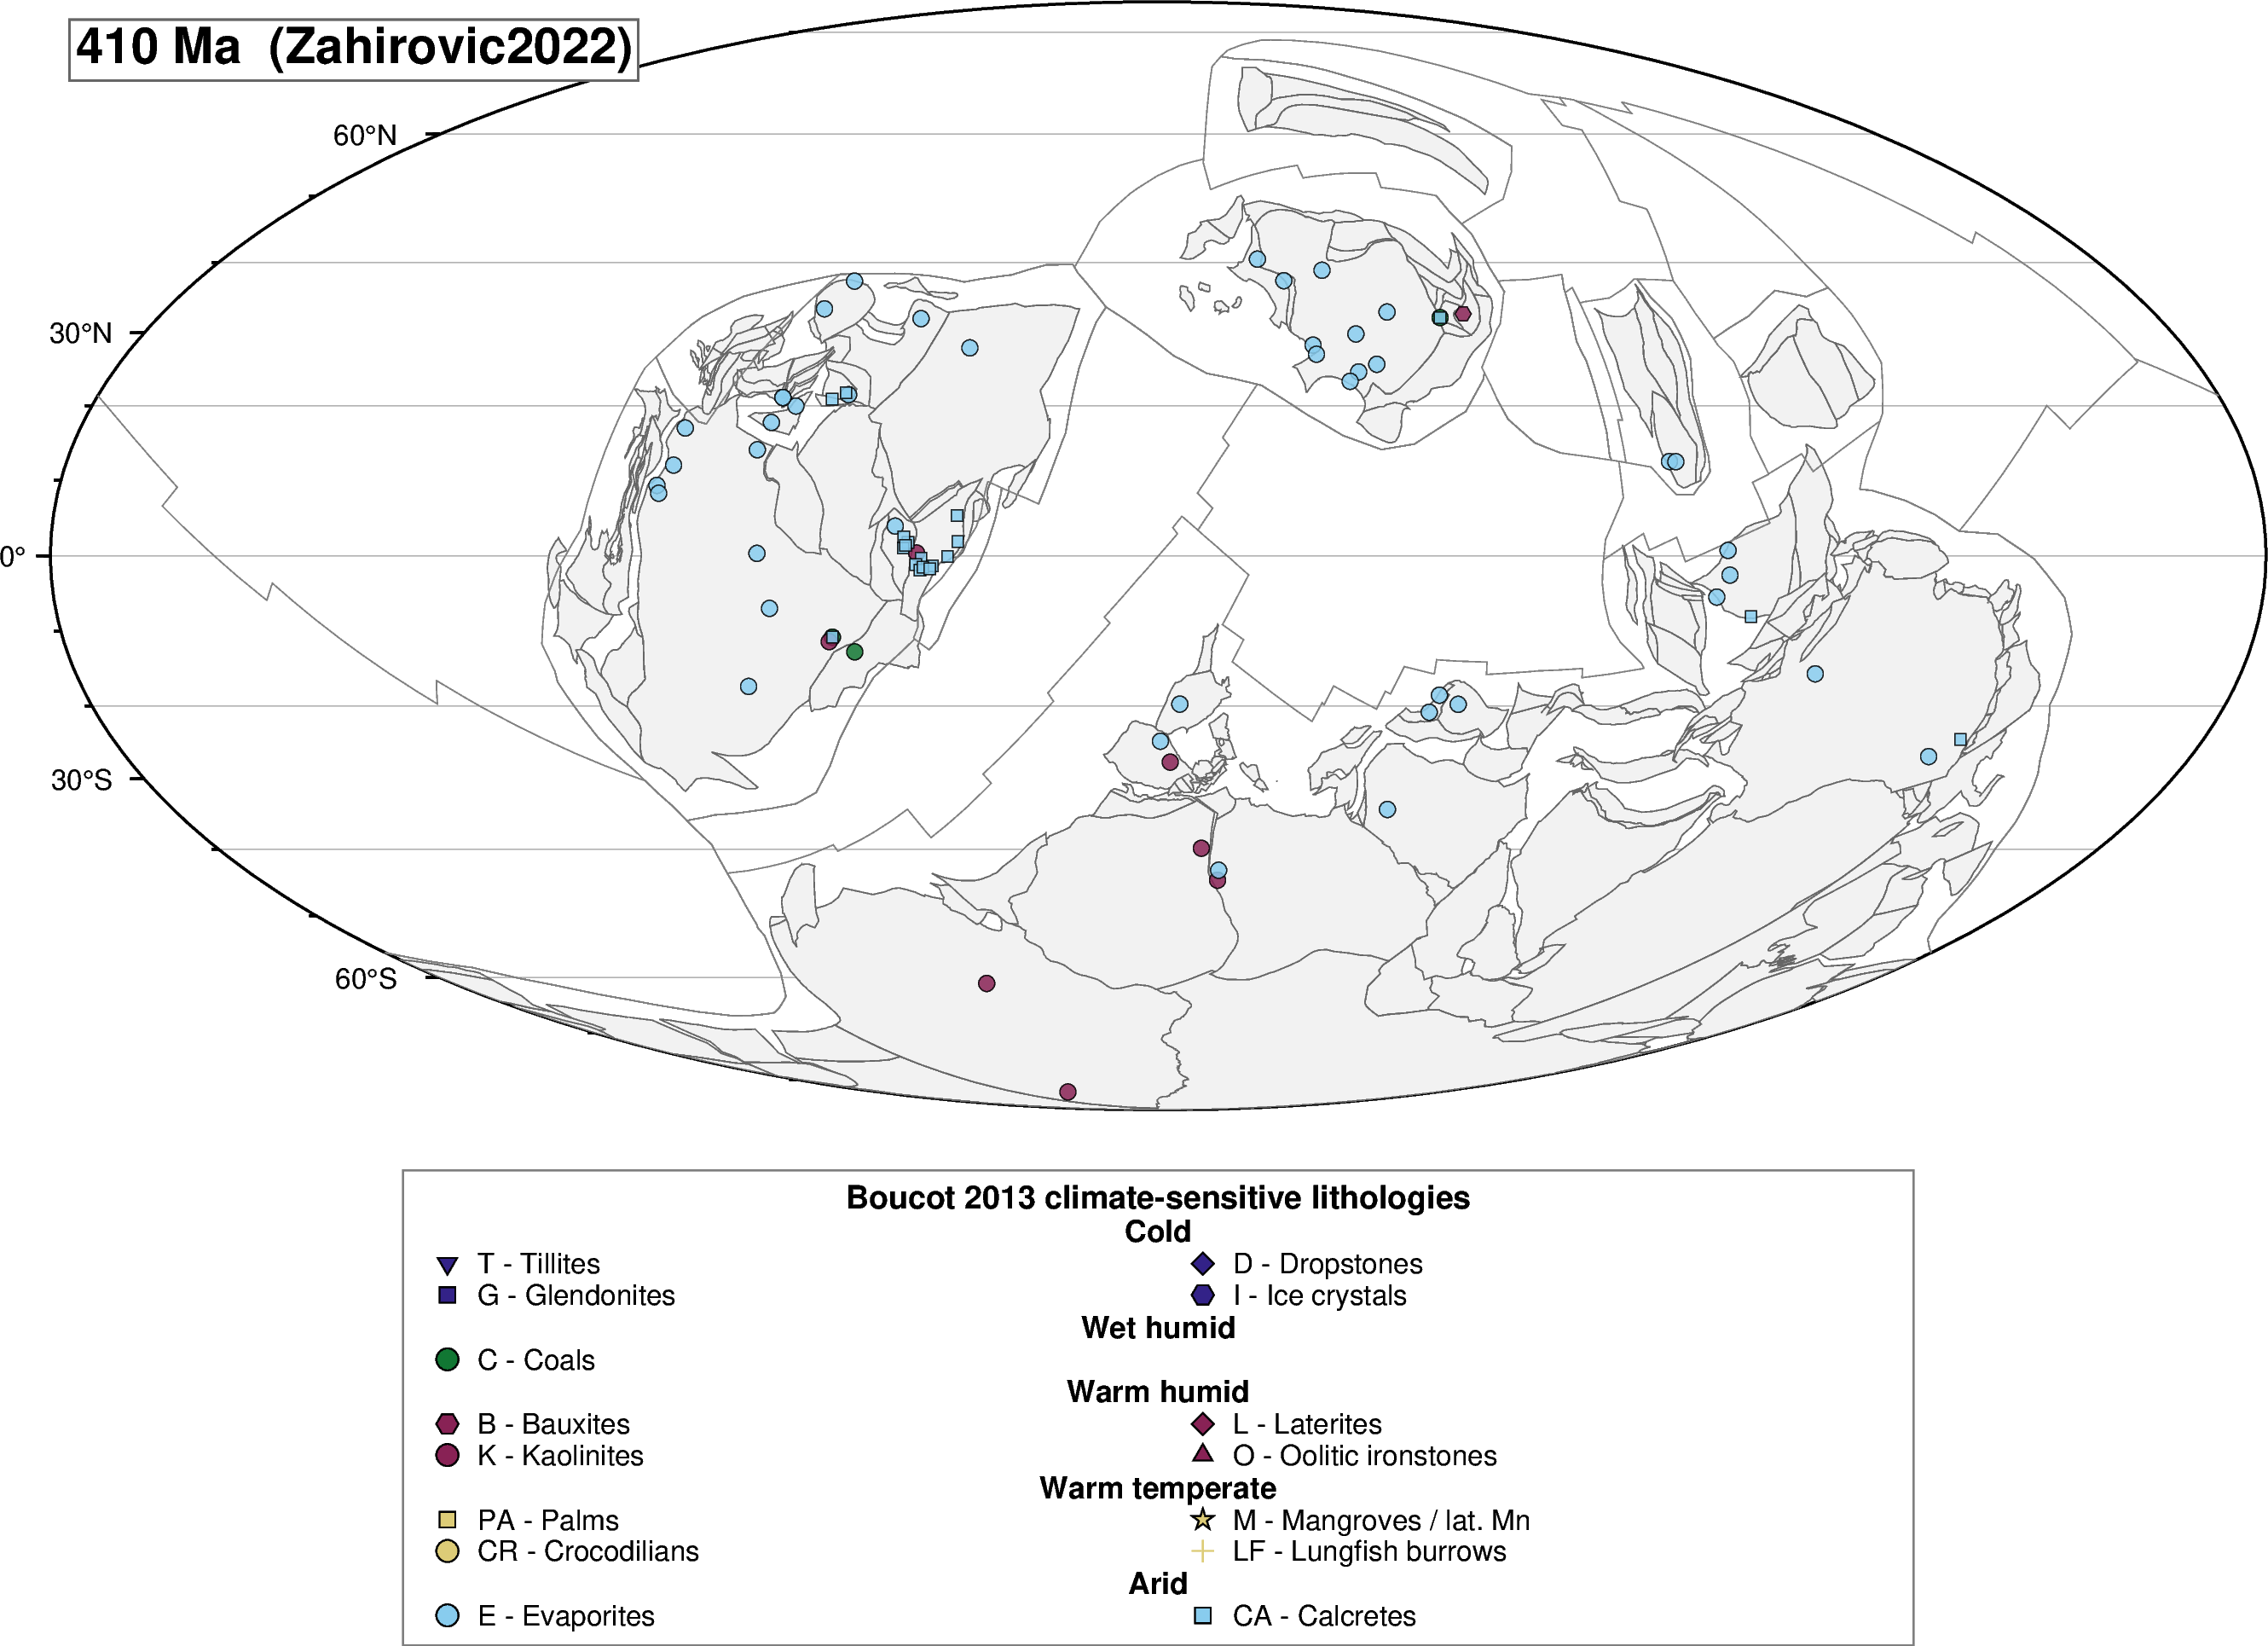

    315 Ma: bins present = ['arid', 'cold', 'warm_humid', 'wet_humid']  |  absent = ['warm_temp']


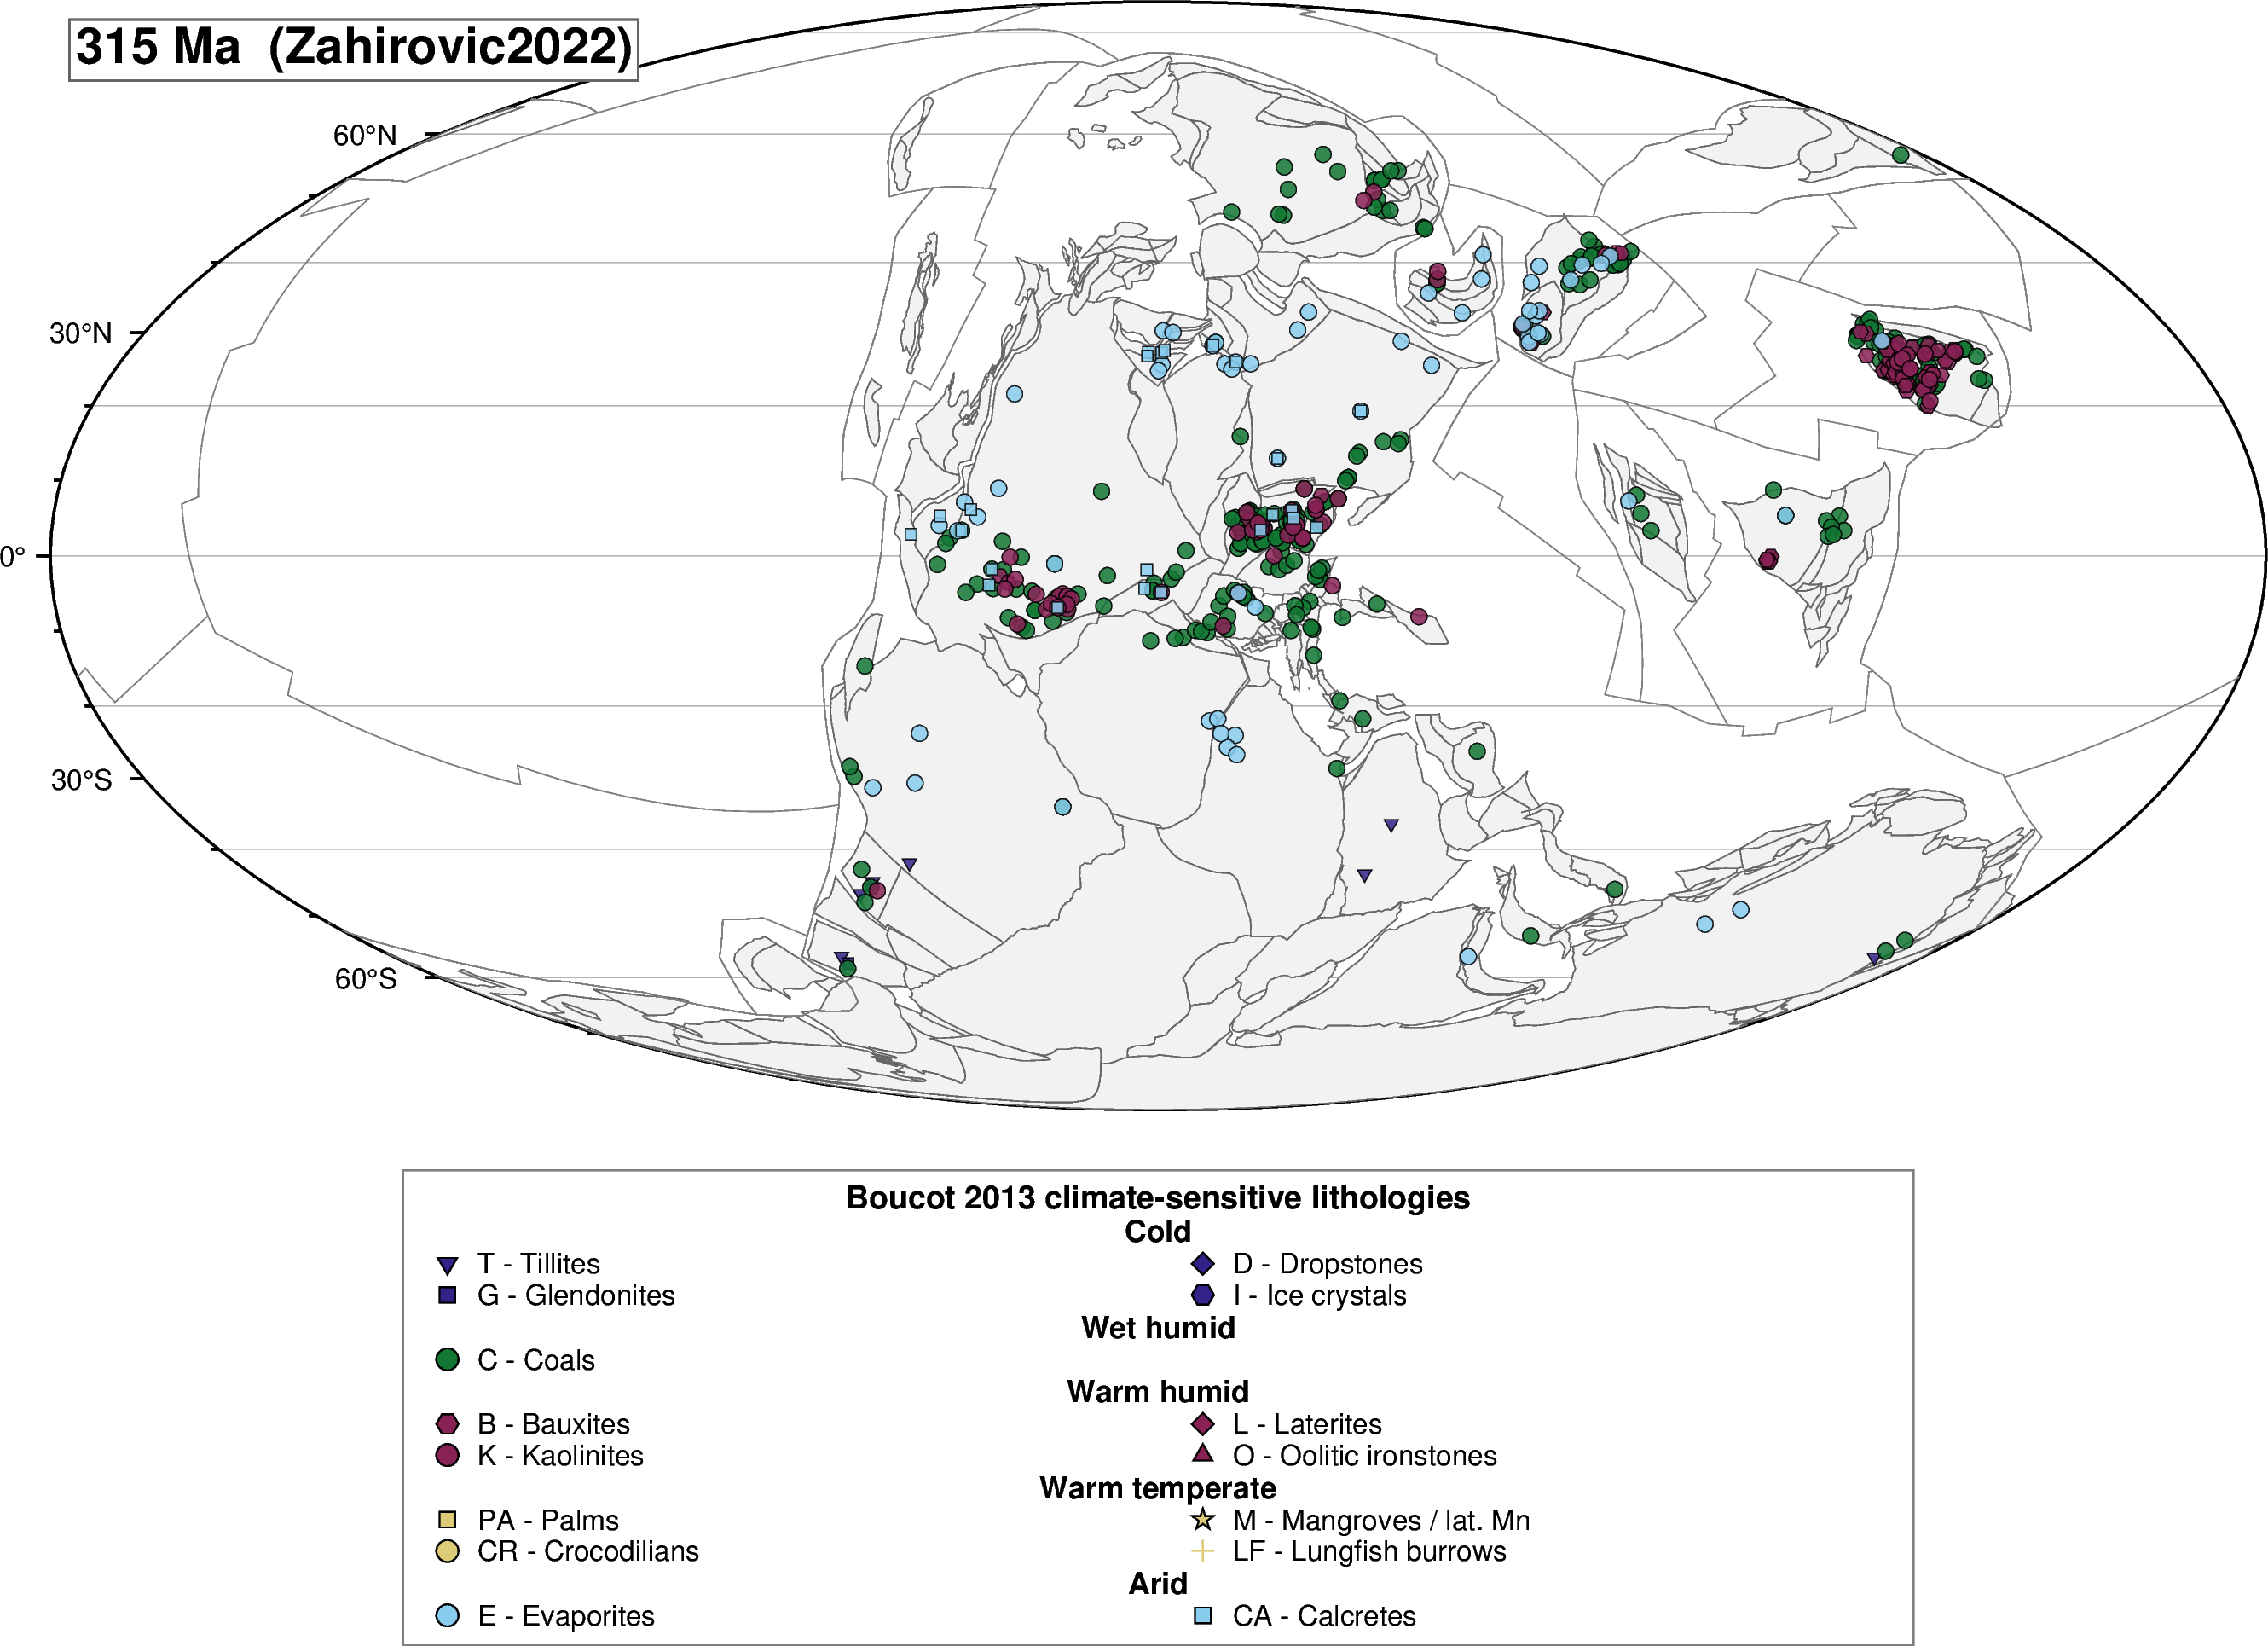

    247 Ma: bins present = ['arid', 'warm_humid', 'warm_temp', 'wet_humid']  |  absent = ['cold']


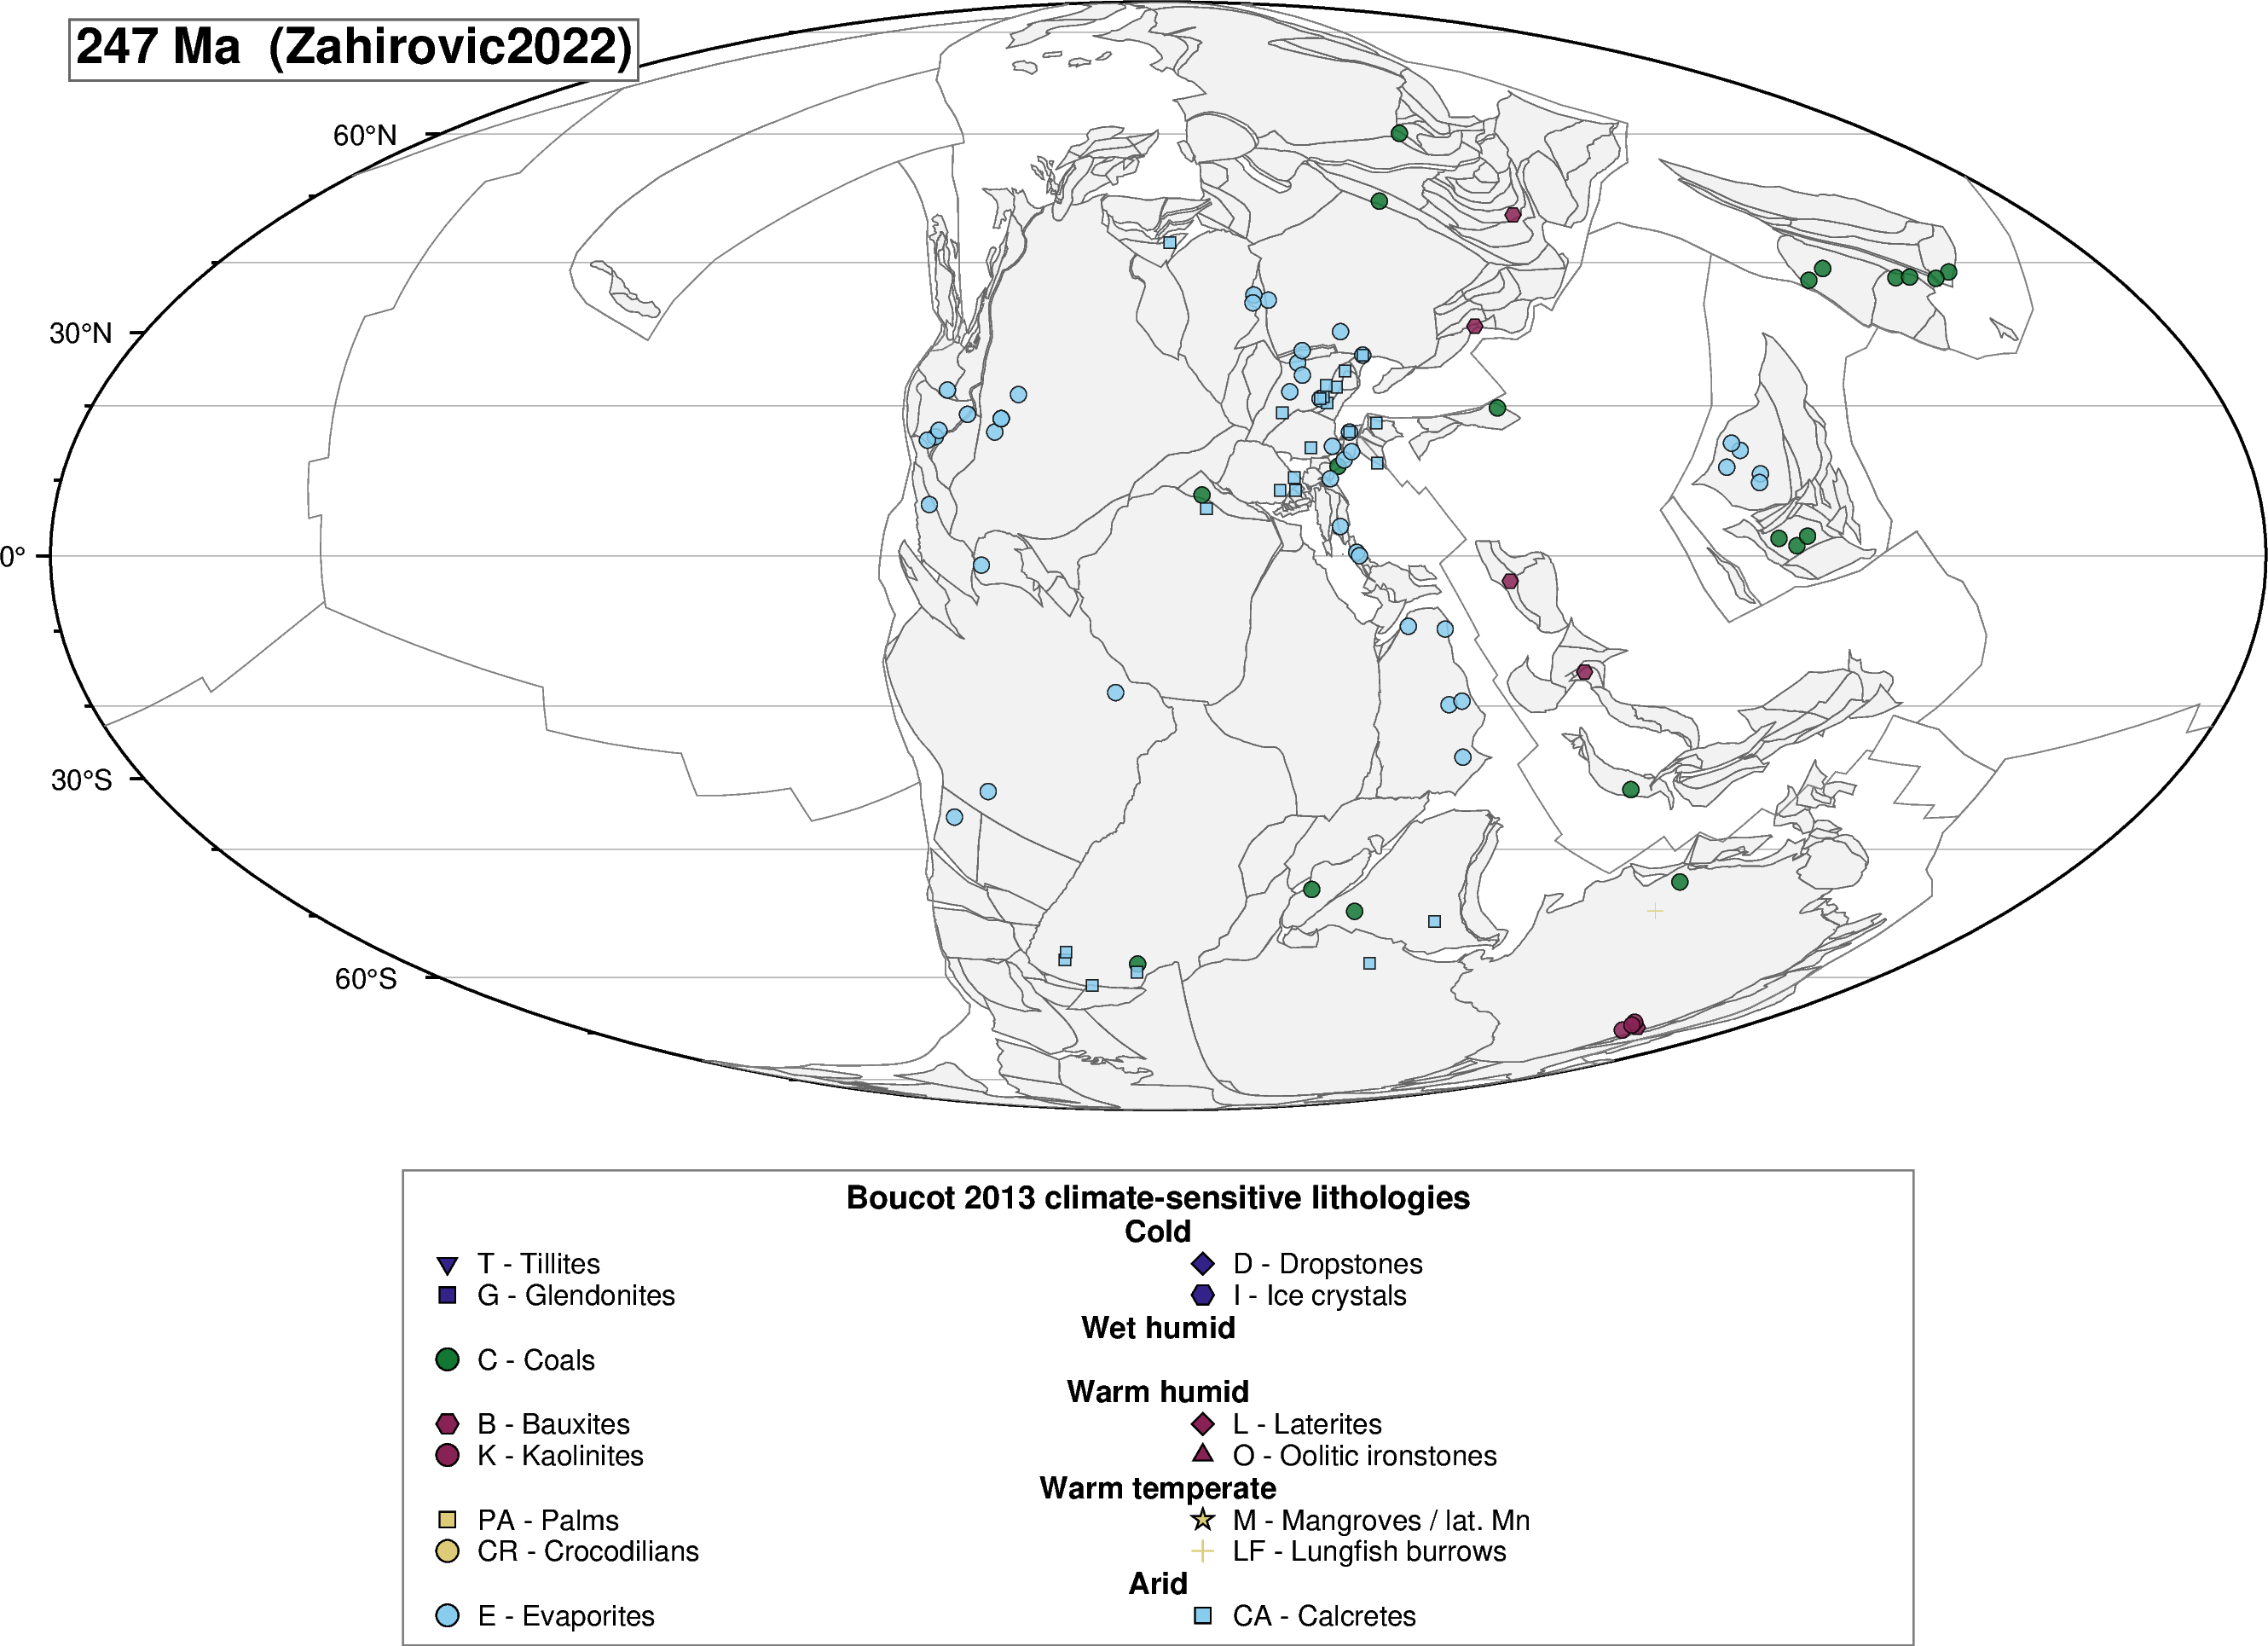

    155 Ma: bins present = ['arid', 'cold', 'warm_humid', 'warm_temp', 'wet_humid']


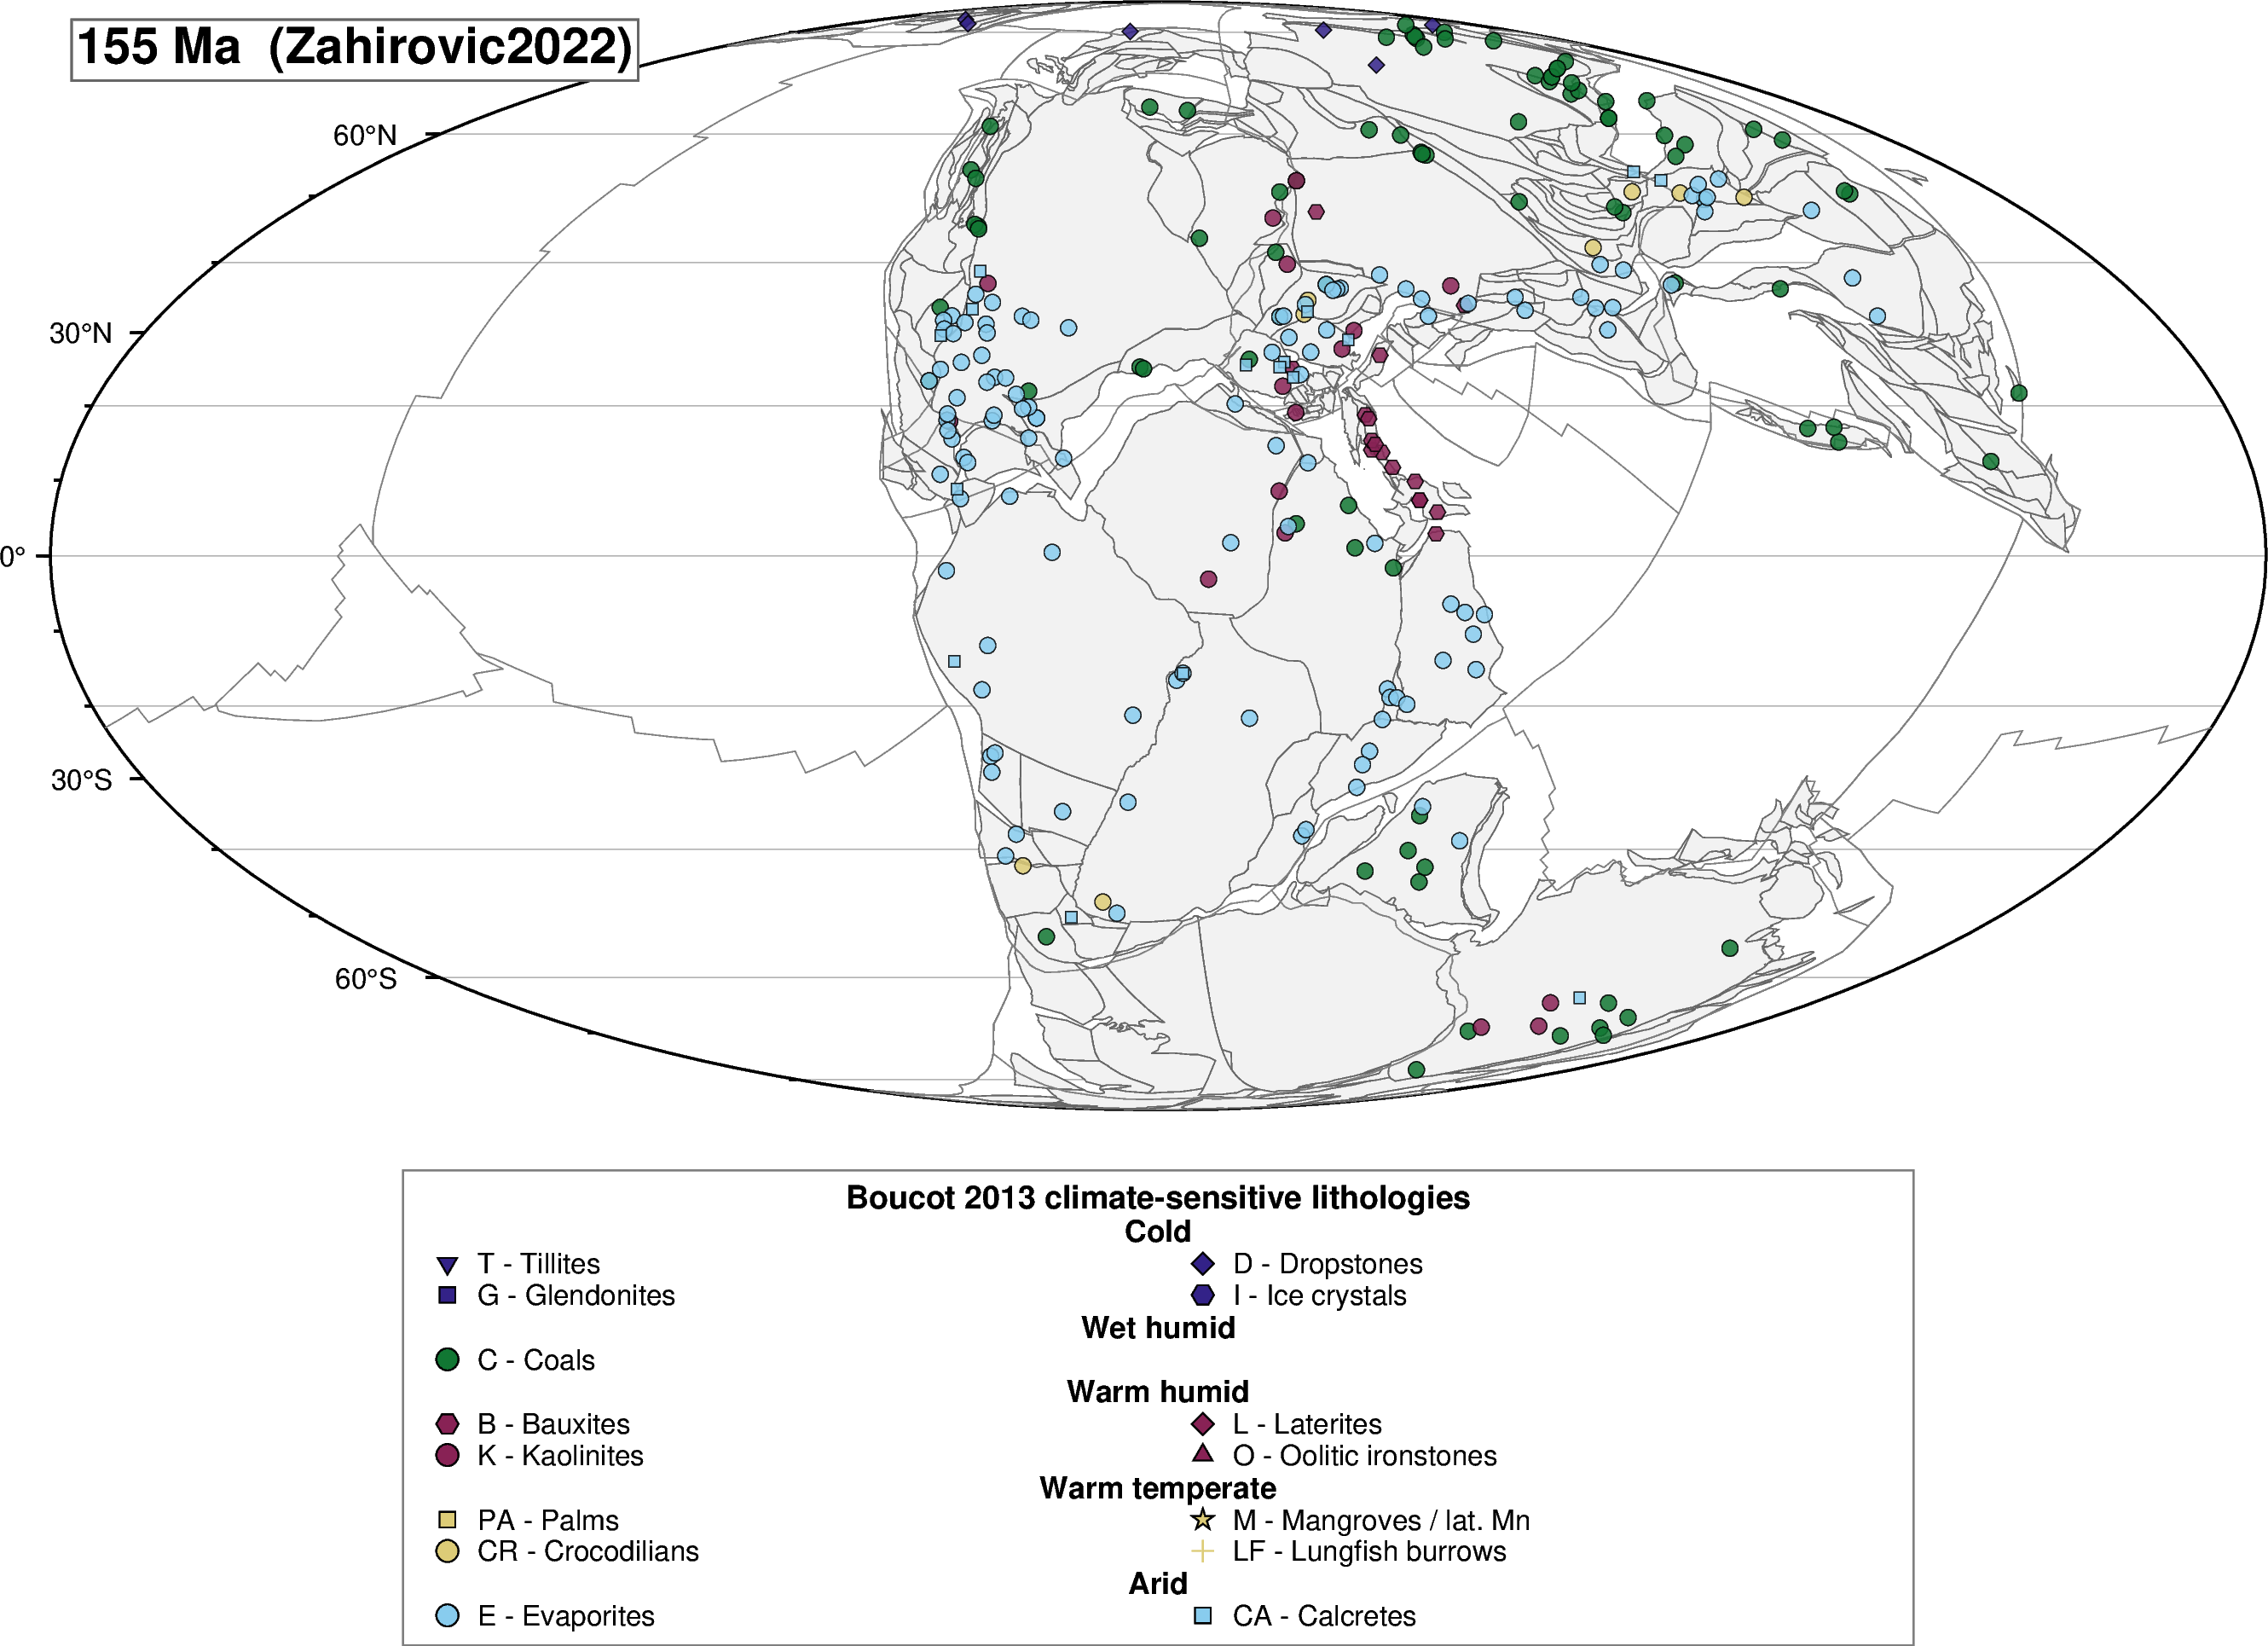

    60 Ma: bins present = ['arid', 'cold', 'warm_humid', 'warm_temp', 'wet_humid']


    15 Ma: bins present = ['arid', 'cold', 'warm_humid', 'warm_temp', 'wet_humid']


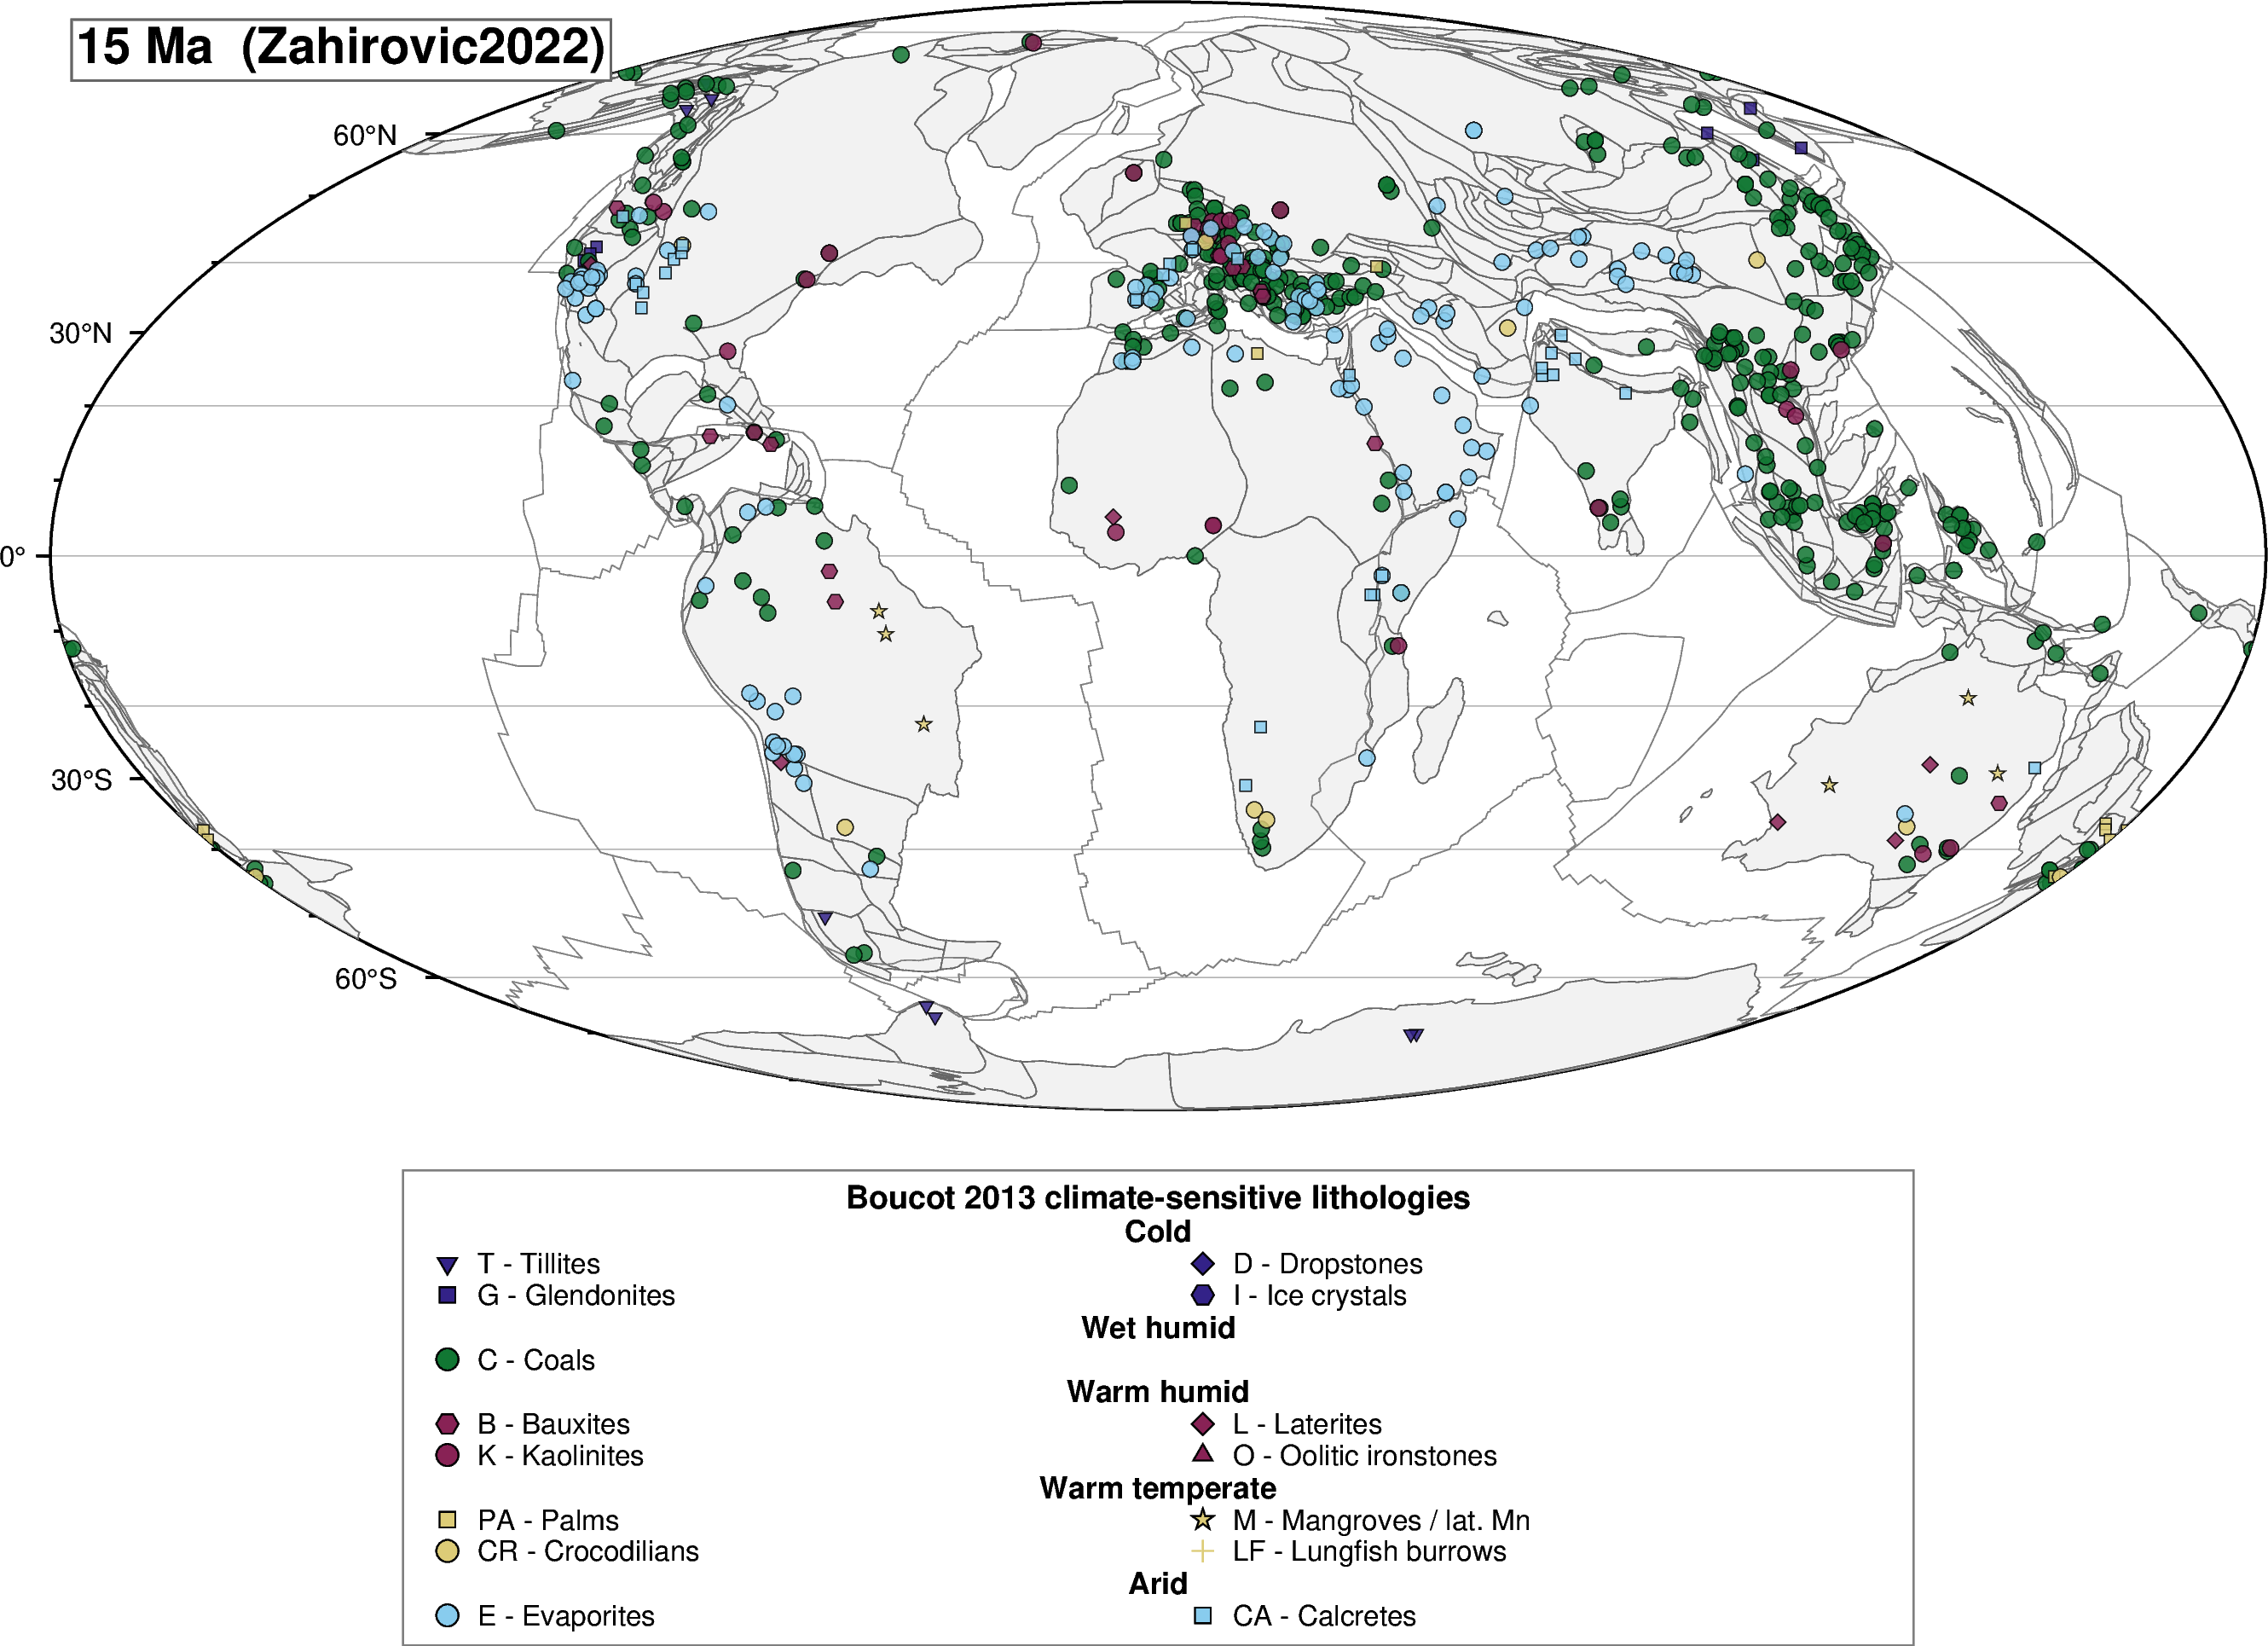

In [5]:
# Cell 4 — six snapshots
for t in SNAPSHOT_TIMES:
    fig = render_lithologies(float(t))
    fig.show(width=1100)
    display(HTML('<div style="height:1cm"></div>'))


## 4. Panel slider — scrub through the full available age range

Row
    [0] IntSlider(end=410, label='Reconstruction t..., name='Reconstruction t..., start=15, step=20, value=250)
    [1] ParamFunction(function, _pane=PNG, defer_load=False)
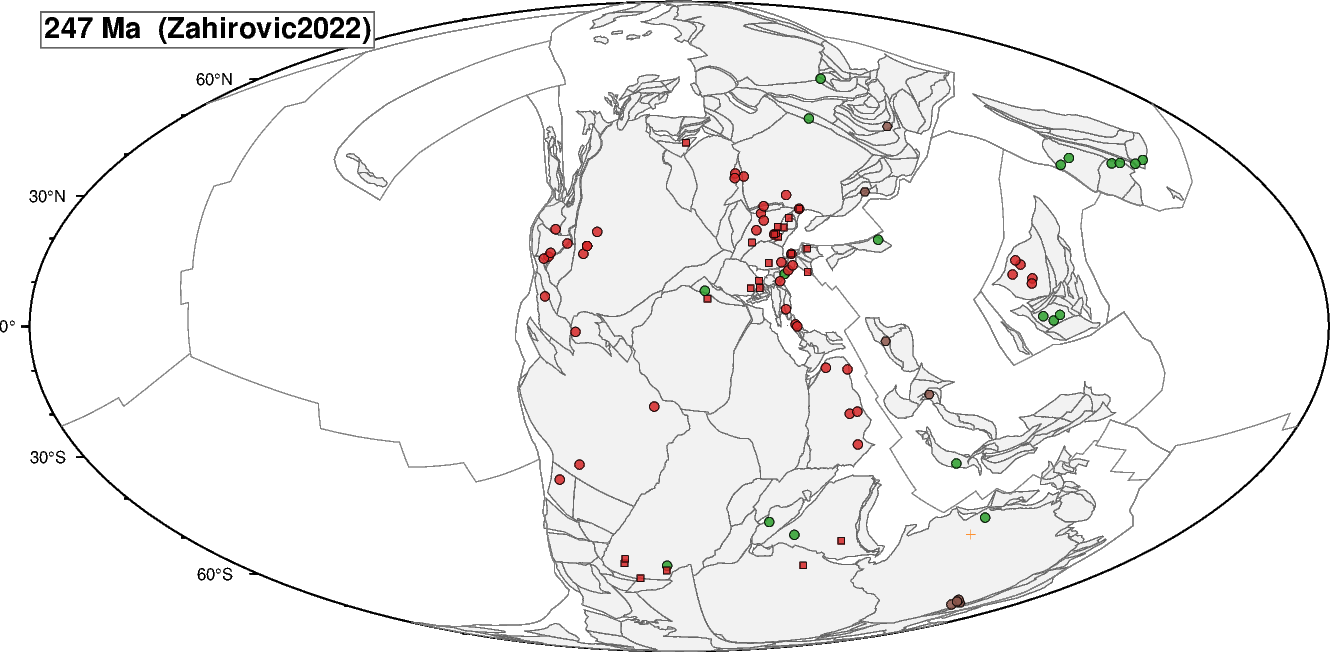

In [6]:
# Cell 5 — slider
def slider_view(t):
    key = nearest_map_key(t)
    a   = MAP_AGE_MA[key]
    out = f"panel_cache/t38_{int(a):03d}.png"
    os.makedirs("panel_cache", exist_ok=True)
    if not os.path.exists(out):
        fig = render_lithologies(float(a))
        fig.savefig(out, dpi=150)
    return pn.pane.PNG(out, width=1000)

slider = pn.widgets.IntSlider(name="Reconstruction time (Ma)",
                              start=int(min(ages)),
                              end=int(min(max(ages), MAX_AGE_MA)),
                              step=SLIDER_STEP_MYR,
                              value=int(SNAPSHOT_TIMES[2]))
pn.Row(slider, pn.bind(slider_view, t=slider))


## 5. Optional — compare Z22's built-in 701701 vs the GPMDB-derived 701702 anchor

**Prerequisite**: T38 (Cell 11) must have been run end-to-end. It writes an *augmented* Z22 rotation file at `data/Zahirovic2022_with_gpmdb_frame.rot` that contains a second synthetic African-plate anchor — **701702** — fit to the Van der Voo–quality-filtered GPMDB 2022 paleomagnetic poles. See T39 for the full frame-by-frame comparison treatment and the explanation of why the two frames diverge in the early Paleozoic.

The cell below renders 350 Ma side-by-side — first under the built-in 701701 frame, then under the GPMDB-derived 701702 frame. The differences are subtle in the Cenozoic / Mesozoic but pronounced in the early Paleozoic. If the augmented rotation file is missing, the cell prints a clear "run T38 first" instruction and stops cleanly.
> **Live-CLI note (GPlately follow-up)**: this notebook currently loads a static snapshot of the GPMDB at `data/paleomag/gpmdb_2022.csv`. Michael Chin fixed the `gplately gpmdb` CLI on the GPlately `master` branch after the GPMDB website's endpoints were redesigned; when a new GPlately release ships, uncomment the CLI block in the load cell to pull a fresh GPMDB snapshot at run time. The bundled CSV stays as an offline fallback.


Comparing Z22 anchor 701701 vs 701702 at 350 Ma
  Z22 built-in 701701 (default)            → 414 continental lithology samples


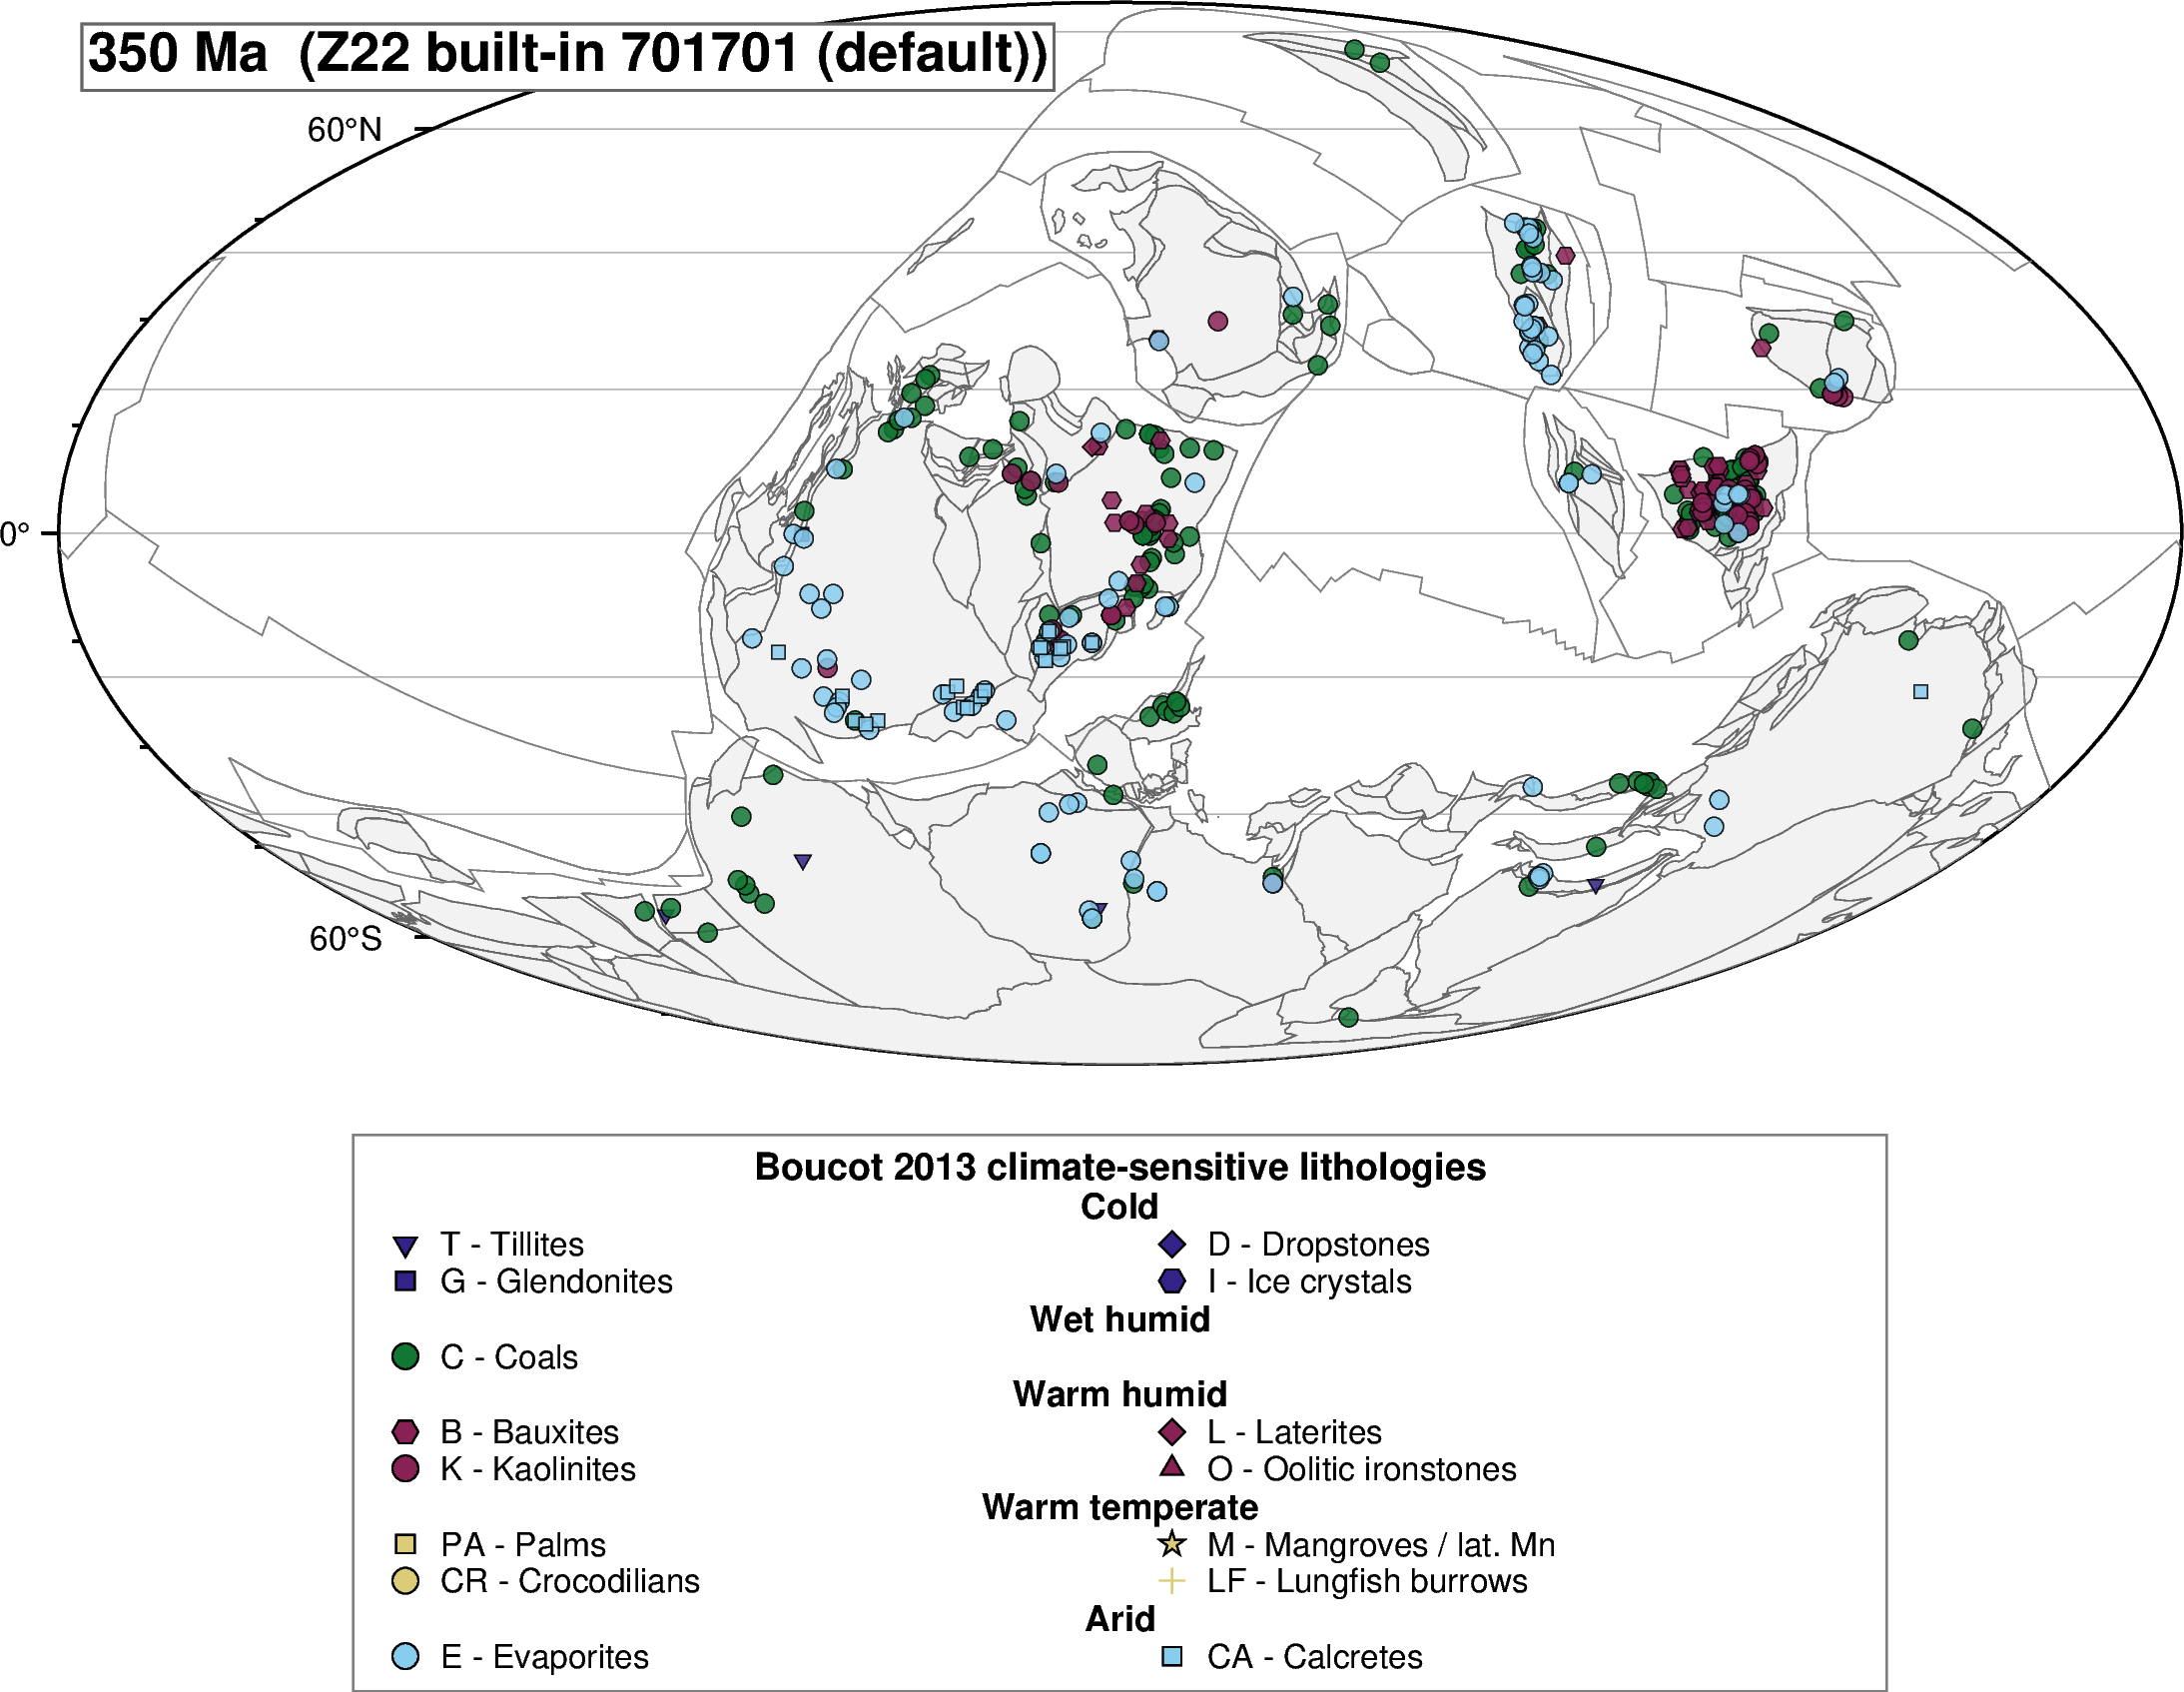

  GPMDB-derived 701702 (T24)               → 414 continental lithology samples


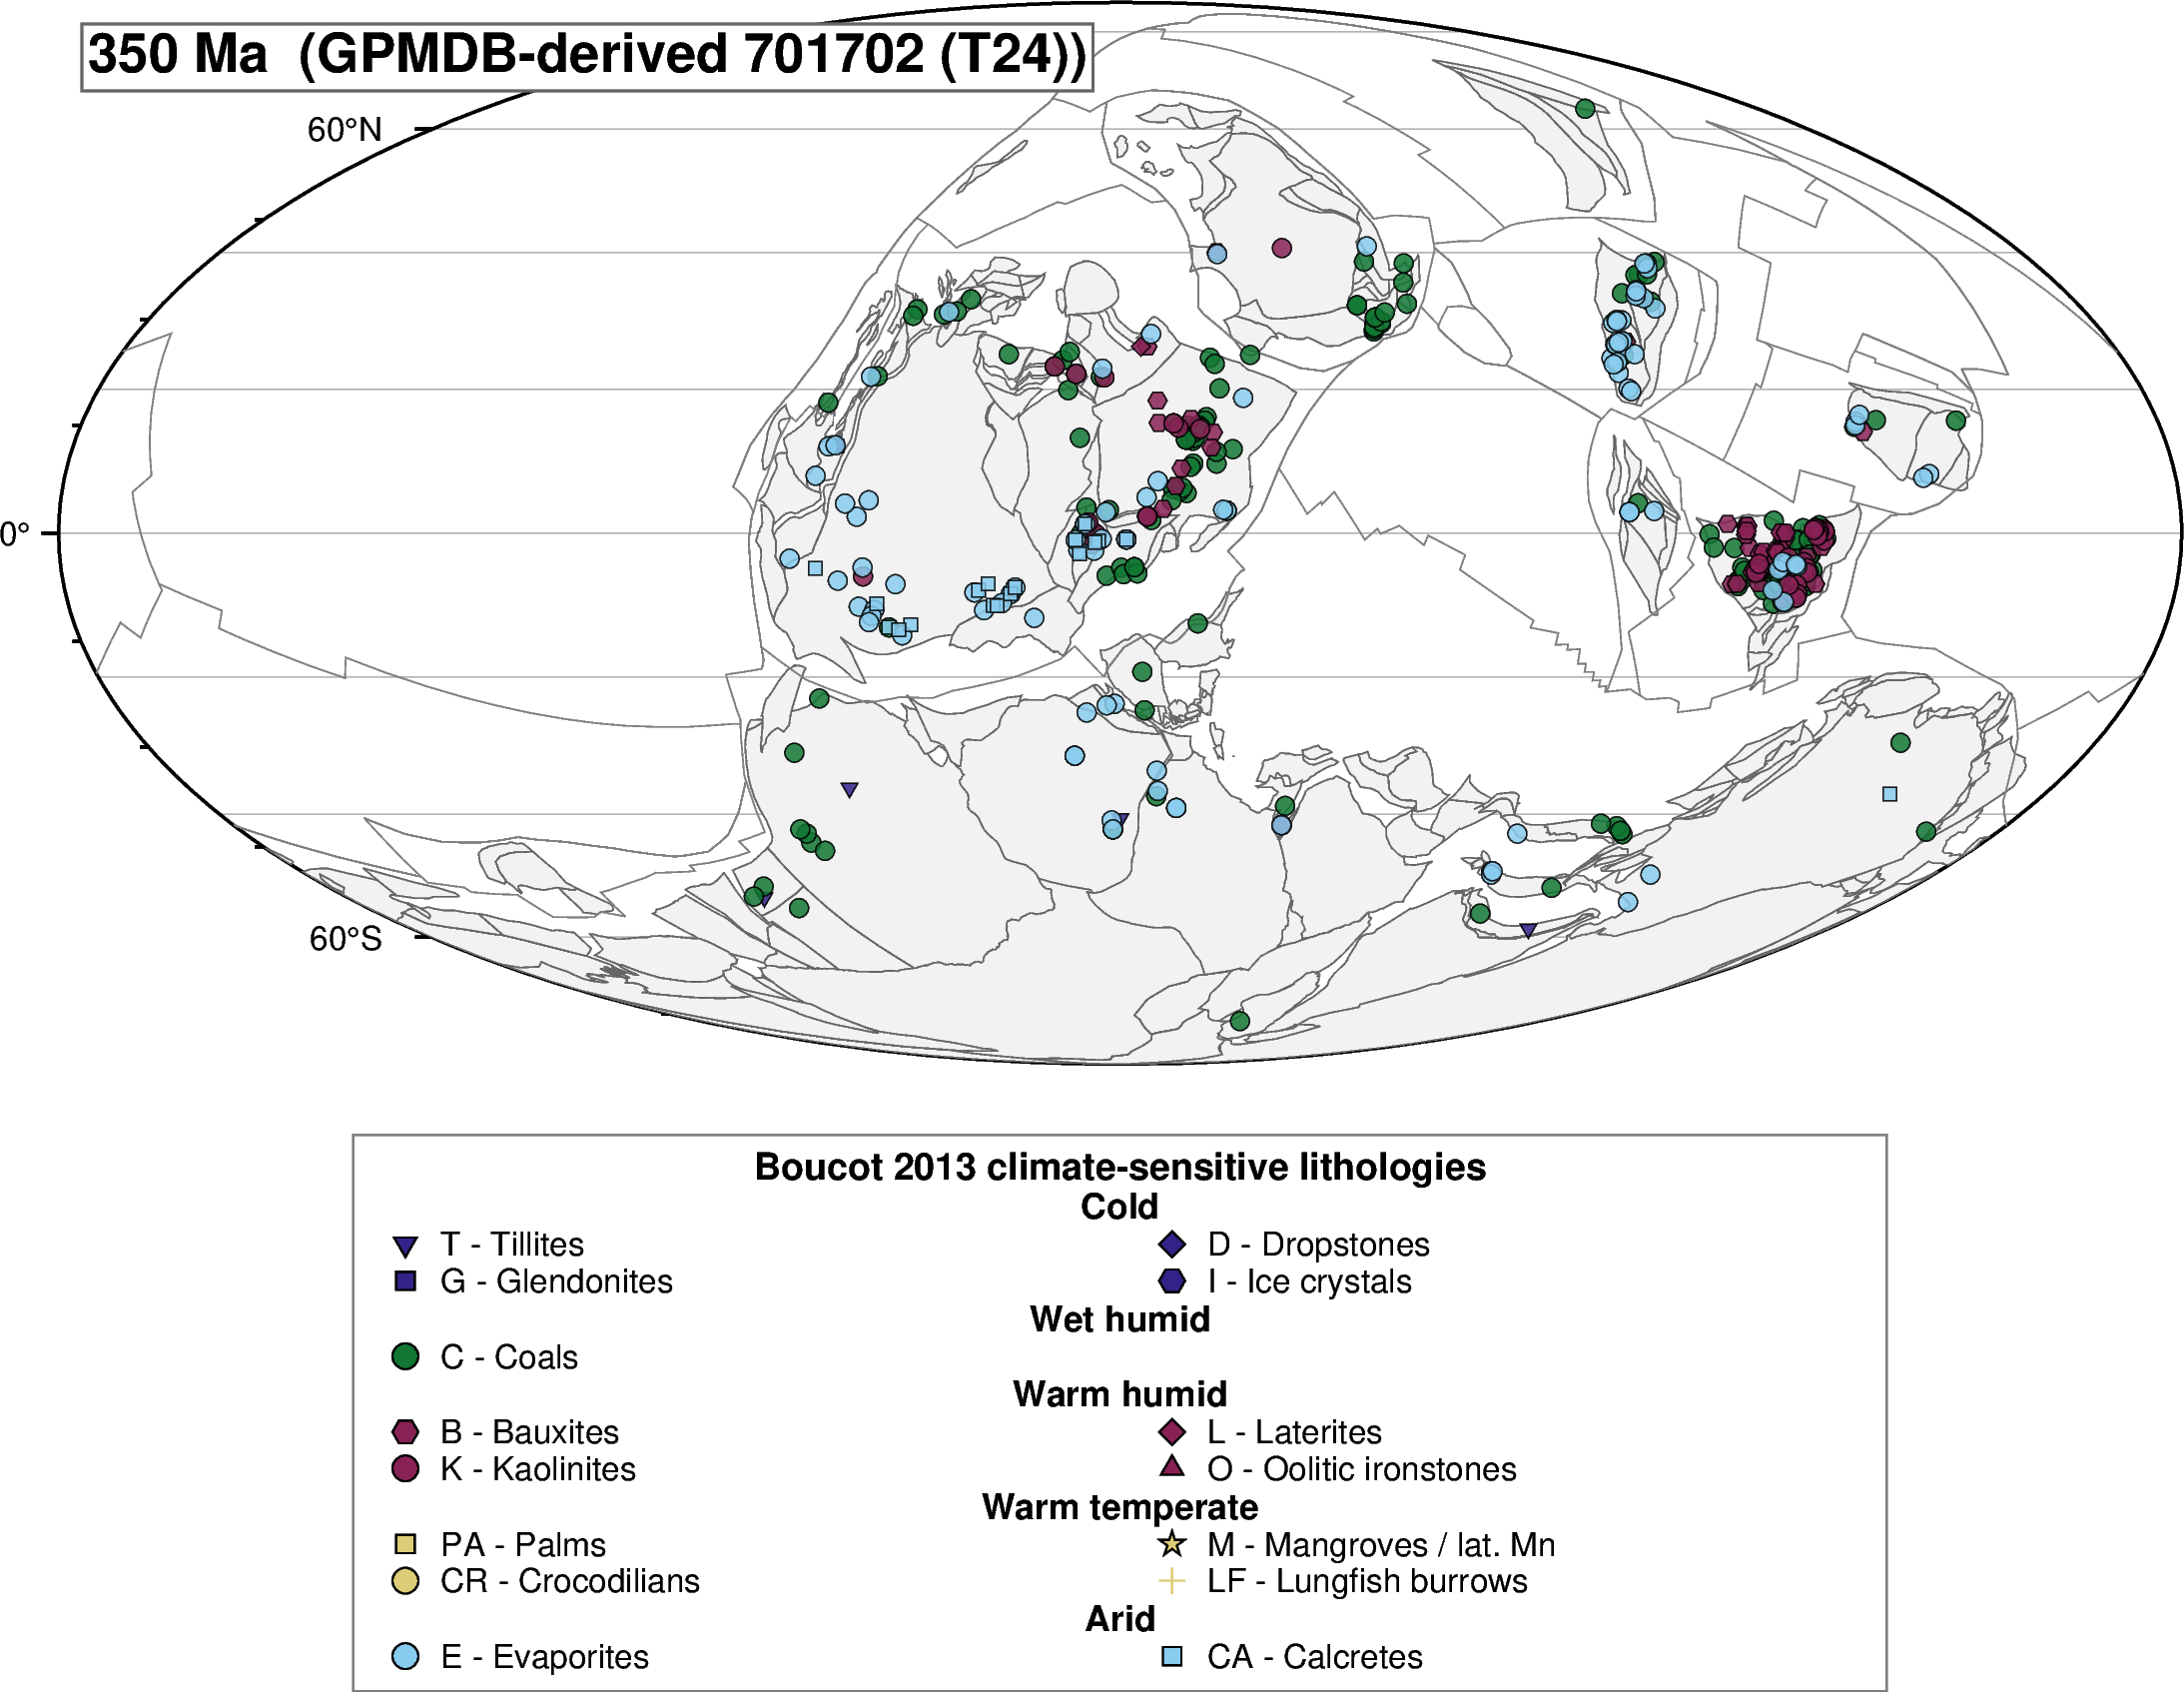

Look at the polar caps (cold-bin tillites + glendonites) and the
equatorial humid belt (coals + bauxites). Early Paleozoic differences
between 701701 and 701702 are most visible at high latitudes and the
paleo-equator. See T25 for paleolatitude time-series of reference
continents under both frames.


In [7]:
# Cell 6 — Optional starter: Z22 paleomag frame 701701 vs 701702 at 350 Ma
# PREREQUISITE: T38 Cell 11 must have written data/Zahirovic2022_with_gpmdb_frame.rot.
AUG_ROT = next((str(p) for p in [
    _Path("data/Zahirovic2022_with_gpmdb_frame.rot"),
    _Path("../data/Zahirovic2022_with_gpmdb_frame.rot"),
] if p.exists()), None)

if AUG_ROT is None:
    print("⚠  Augmented Z22 rotation file not found.")
    print("   Expected at: data/Zahirovic2022_with_gpmdb_frame.rot")
    print("   Run T38 first — its Cell 11 writes this file by appending a 701702")
    print("   anchor (derived from the GPMDB 2022 Q-filtered APWP) to the Z22")
    print("   rotation file. Then re-run this cell. T39 demonstrates the full")
    print("   frame-comparison workflow this cell is a lithology-flavoured riff on.")
else:
    COMPARE_AGE_MA = 350.0
    key = nearest_map_key(COMPARE_AGE_MA)
    a   = MAP_AGE_MA[key]
    assert a <= MAX_AGE_MA

    _rot_by_anchor = {
        701701: pygplates.RotationModel(AUG_ROT, default_anchor_plate_id=701701),
        701702: pygplates.RotationModel(AUG_ROT, default_anchor_plate_id=701702),
    }
    _labels = {701701: "Z22 built-in 701701 (default)",
               701702: "GPMDB-derived 701702 (T38)"}

    def _render_alt_frame(anchor_id):
        rot = _rot_by_anchor[anchor_id]
        df  = BOUCOT[key].copy()

        # Build a recon + gplot specific to this anchor
        _recon = gplately.PlateReconstruction(
            rotation_model=rot, topology_features=model.get_topologies(),
            static_polygons=model.get_static_polygons(),
            anchor_plate_id=anchor_id)
        pts = gplately.Points(_recon, df["present_lon"].values, df["present_lat"].values,
                              anchor_plate_id=anchor_id)
        rlon, rlat = pts.reconstruct(float(a), anchor_plate_id=anchor_id, return_array=True)
        if len(rlon) < len(df):
            df = df.iloc[:len(rlon)].copy().reset_index(drop=True)
        df["paleo_lon"] = rlon; df["paleo_lat"] = rlat
        df = df[df["paleo_lon"].notna() & df["paleo_lat"].notna()].reset_index(drop=True)

        _gplot = gplately.PlotTopologies(
            plate_reconstruction=_recon,
            coastlines=model.get_coastlines(),
            continents=model.get_continental_polygons(),
            COBs=model.get_COBs(),
            time=float(a),
        
        plot_engine=gplately.PygmtPlotEngine(),
        )
        from shapely.geometry import Point as _Point
        from shapely.ops import unary_union as _unary_union
        from shapely.prepared import prep as _prep
        cont = _gplot.get_continents()
        if cont is not None and len(cont) > 0:
            uni = _prep(_unary_union(list(cont.geometry)))
            inside = np.fromiter(
                (uni.contains(_Point(lo, la))
                 for lo, la in zip(df["paleo_lon"], df["paleo_lat"])),
                dtype=bool, count=len(df))
            df = df.loc[inside].reset_index(drop=True)

        fig = pygmt.Figure()
        pygmt.config(MAP_GRID_PEN_PRIMARY="0.25p,gray70")
        fig.basemap(region="d", projection="W0/18c", frame=["af", "yg20"])
        try:
            _gplot.plot_continents(fig, fill="gray95", pen="0.3p,gray40")
        except Exception: pass
        try:
            _gplot.plot_all_topological_sections(fig, pen="0.3p,gray50")
        except Exception: pass
        codes_here = [c for c in LITHO_KEY if c in df["code"].values]
        for code in codes_here:
            sub = df[df["code"] == code]
            fig.plot(x=sub["paleo_lon"], y=sub["paleo_lat"],
                     style=f"{LITHO_SHAPE[code]}0.16c",
                     fill=LITHO_COLOR[code], pen="0.25p,black", transparency=15)
        # Legend below the map (matches the §3 render_lithologies layout).
        fig.legend(spec=_write_bin_legend(),
                   position="JBC+jTC+o0c/0.6c+w13c",
                   box="+gwhite+p0.5p,gray50")
        fig.text(text=f"{a:.0f} Ma  ({_labels[anchor_id]})",
                 position="TL", offset="0.25c/-0.25c", justify="TL",
                 font="13p,Helvetica-Bold,black", fill="white", pen="0.6p,gray40")
        return fig, len(df)

    print(f"Comparing Z22 anchor 701701 vs 701702 at {a:.0f} Ma")
    for anchor in (701701, 701702):
        fig, n_pts = _render_alt_frame(anchor)
        print(f"  {_labels[anchor]:40s} → {n_pts} continental lithology samples")
        fig.show(width=900)
        display(HTML('<div style="height:1cm"></div>'))
    print("Look at the polar caps (cold-bin tillites + glendonites) and the")
    print("equatorial humid belt (coals + bauxites). Early Paleozoic differences")
    print("between 701701 and 701702 are most visible at high latitudes and the")
    print("paleo-equator. See T39 for paleolatitude time-series of reference")
    print("continents under both frames.")


## Extend this

- **Apply the GPMDB-derived 701702 anchor across the full notebook.** §5 already renders 350 Ma side-by-side for Z22's built-in 701701 vs the new 701702 anchor T38 fits to GPMDB 2022 poles. T39 shows the two frames diverge most strongly in the early Paleozoic — a several-degree paleolatitude offset on continents like Laurentia. **Exercise:** modify Cell 4 to load `pygplates.RotationModel(data/Zahirovic2022_with_gpmdb_frame.rot, default_anchor_plate_id=701702)`, set `ANCHOR_PLATE_ID = 701702`, and re-run §3 + §4. Look at where coals (humid bin) and evaporites (arid bin) land on 400 Ma Laurentia and Baltica under each frame. **Setup**: requires running T38 end-to-end first (its Cell 11 writes the augmented rotation file); read T39 for the full conceptual treatment. The new rotations cannot be downloaded from PMM — they only exist locally once T38 has been executed.
- **Push past 410 Ma — swap to Merdith 2021.** Change `MODEL_NAME = "Merdith2021"`, `ANCHOR_PLATE_ID = 0`, and `MAX_AGE_MA = 540.0` (or higher). The loader will pick up the Lower Cambrian → Lower Devonian Boucot maps that Z22 cannot reach. Boucot's Cambrian and Ordovician lithology coverage is sparse (the global record is patchy for that age) but informative — for example the Cambrian evaporites of Siberia + North America are key evidence for the bipolar arid belts in Boucot's reconstruction.
- **Per-bin area through time.** For each climate bin, compute the global continental-area fraction occupied by its samples at every age and chart it. The result tells you how the wet-humid / arid / cold area fractions evolved through the Phanerozoic under the user's plate model — directly comparable to the GCM-based climate-belt-area time series.
- **Compare lithology-derived bins against a deep-time climate model.** Run a HadCM3 (T67) or cGENIE (T65) snapshot at the same age, classify the model's output into the same five climate bins via temperature/precipitation thresholds, and check whether the model places each Boucot lithology in the bin its climate code implies. Disagreements highlight either model bias or proxy mis-classification.
- **Cross-reference T63 (plant-fossil PFT climate proxies).** T63 applies the same climate-sensitive-point-data idea to Permian-Triassic plant-fossil occurrences instead of lithologies -- compare where each notebook's proxy places the climate belts around the mass-extinction boundary.
- **Tighten the continental mask.** The current filter accepts any sample inside the reconstructed continental polygons. A more conservative test would require the sample to be located on emergent (subaerial) crust at the snapshot age — bring in a paleo-bathymetry or paleotopography grid and require positive elevation.
- **Per-bin per-paleolatitude band density.** Group reconstructed lithology counts into 10° paleolatitude bands and bar-chart per bin. The expected pattern — coals at high & mid lats + equatorial; evaporites at ~±30°; tillites at the poles; palms/crocodilians at low-to-mid lats — is the most direct quantitative test of Boucot's climate-band interpretation.

## References

- Boucot, A.J., Xu, C. & Scotese, C.R. (2013). *Phanerozoic Paleoclimate: An Atlas of Lithologic Indicators of Climate*. SEPM Concepts in Sedimentology and Paleontology No. 11. https://doi.org/10.2110/sepmcsp.11
- Zahirovic, S., Eleish, A., Doss, S., Pall, J., Cannon, J., Pistone, M., Tetley, M.G., Young, A. & Fox, P. (2022). Subduction and carbonate platform interactions. *Geoscience Data Journal* 9(2), 371-383. https://doi.org/10.1002/gdj3.146
- Merdith, A.S., Williams, S.E., Collins, A.S., Tetley, M.G., Mulder, J.A., Blades, M.L., Young, A., Armistead, S.E., Cannon, J., Zahirovic, S. & Müller, R.D. (2021). Extending full-plate tectonic models into deep time: Linking the Neoproterozoic and the Phanerozoic. *Earth-Science Reviews* 214, 103477. (Alternative FORWARD model for the >410 Ma extension.)
- Mather, B.R. et al. (2024). GPlately. *Geoscience Data Journal* 11, 3–10.
- Tian, D., Uieda, L., Leong, W.J., Fröhlich, Y., Schlitzer, W., Grund, M., Jones, M., Toney, L., Yao, J., Magen, Y., Tong, J.-H., Ngo, L., Materna, K., Belem, A., Newton, T., Anant, A., Ziebarth, M., Quinn, J. & Wessel, P. (2024). PyGMT: A Python interface for the Generic Mapping Tools. *Zenodo*. https://doi.org/10.5281/zenodo.13679420
- Wessel, P., Luis, J.F., Uieda, L., Scharroo, R., Wobbe, F., Smith, W.H.F. & Tian, D. (2019). The Generic Mapping Tools version 6. *Geochemistry, Geophysics, Geosystems* 20(11), 5556–5564. https://doi.org/10.1029/2019GC008515
